In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib import cm as cm
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable
import skccm
from skccm import Embed
from skccm import CCM
from skccm.utilities import train_test_split
from shapely.geometry import LineString

In [2]:
names = {"St.David": 7, "Contention": 6, "Fairbank": 1, "Boquillas": 8, "CharlestonMesquite": 2, "Moson": 3, "Hunter": 4, "Hereford": 5}

In [3]:
names.values()

dict_values([7, 6, 1, 8, 2, 3, 4, 5])

# Seasons
* Cool-Season Recharge: Dec 1 - Mar 31
* Pre-Monsoon Dry: Apr 1 - Jun 30
* Monsoon: Jul 1 - Sep 30
* Post-Monsoon Recession: Oct 1 - Nov 30

Defined by CLIMAS and NOAA/NWS:
* https://climas.arizona.edu/sites/default/files/2025-06/May-2025-Southwest-Climate-Outlook.pdf
* https://www.azwater.gov/news/articles/2025-05-21


In [4]:
flow = pd.read_csv("USPPFlowMonitoring2006_2025.csv")
flow = flow[~flow["Site"].isin(["Cottonwood", "Escalante", "FairbankNorth"])]
flow = gpd.GeoDataFrame(flow, geometry = gpd.points_from_xy(flow["Longitude"], flow["Latitude"]))
flow["Camera"] = flow["Site"].map(names).astype("Int64")
flow["Date"] = pd.to_datetime(flow["Date"])
flow["Month"] = flow["Date"].dt.month

In [5]:
def season(month):
    if month in [12, 1, 2, 3]:
        return 1
    elif month in [4, 5, 6]:
        return 2
    elif month in [7, 8, 9]:
        return 3
    elif month in [10, 11]:
        return 4

flow["Season"] = flow["Month"].apply(season)

def water_year(date):
    if date.month >= 10:
        return date.year + 1
    return date.year

flow["WY"] = flow["Date"].apply(water_year)

def recode(fc):
    if fc in [1, 2]:
        return 1
    elif fc == 0:
        return 0
    else:
        return np.nan
    
flow["Persistence"] = flow["Flow Code"].apply(recode)

flow = flow[~flow["Site"].isin(["Cottonwood", "Escalante", "FairbankNorth", "LewisSprings"])]
flow = gpd.GeoDataFrame(flow, geometry = gpd.points_from_xy(flow["Longitude"], flow["Latitude"]), crs = "EPSG:4326")
flow = flow.to_crs(epsg = 32612)
flow = flow.sort_values(by = "Latitude")
river = LineString(flow.geometry.tolist())

def river_km(point):
    return river.project(point)/1000

flow["River Kilometer"] = flow["geometry"].apply(river_km)
flow.head()

c:\Users\tiffa\anaconda3\Lib\site-packages\shapely\linear.py:88: RuntimeWarning: invalid value encountered in line_locate_point
  return lib.line_locate_point(line, other)


,Site,Date,Flow Code,Latitude,Longitude,Notes,File Name,geometry,Camera,Month,Season,WY,Persistence,River Kilometer
5156,Hereford,2007-10-07,2.0,31.461756,-110.109676,NaN,USPPFlowMonitoring 01_2020.xls,POINT (584585 3481121),5,10,4,2008,1.0,0.0
5164,Hereford,2007-10-08,2.0,31.461756,-110.109676,NaN,USPPFlowMonitoring 01_2020.xls,POINT (584585 3481121),5,10,4,2008,1.0,0.0
5172,Hereford,2007-10-09,2.0,31.461756,-110.109676,NaN,USPPFlowMonitoring 01_2020.xls,POINT (584585 3481121),5,10,4,2008,1.0,0.0
5180,Hereford,2007-10-10,2.0,31.461756,-110.109676,NaN,USPPFlowMonitoring 01_2020.xls,POINT (584585 3481121),5,10,4,2008,1.0,0.0
5124,Hereford,2007-10-03,2.0,31.461756,-110.109676,NaN,USPPFlowMonitoring 01_2020.xls,POINT (584585 3481121),5,10,4,2008,1.0,0.0


In [6]:
seasons = flow.dropna(subset = ["Persistence"]).groupby(["Camera", "WY", "Season", "River Kilometer"])["Persistence"].mean().reset_index()

In [7]:
seasons.head()

,Camera,WY,Season,River Kilometer,Persistence
0,1,2006,2,30.017126,0.394366
1,1,2006,3,30.017126,0.717391
2,1,2007,1,30.017126,1.000000
3,1,2007,2,30.017126,0.666667
4,1,2007,3,30.017126,0.826087


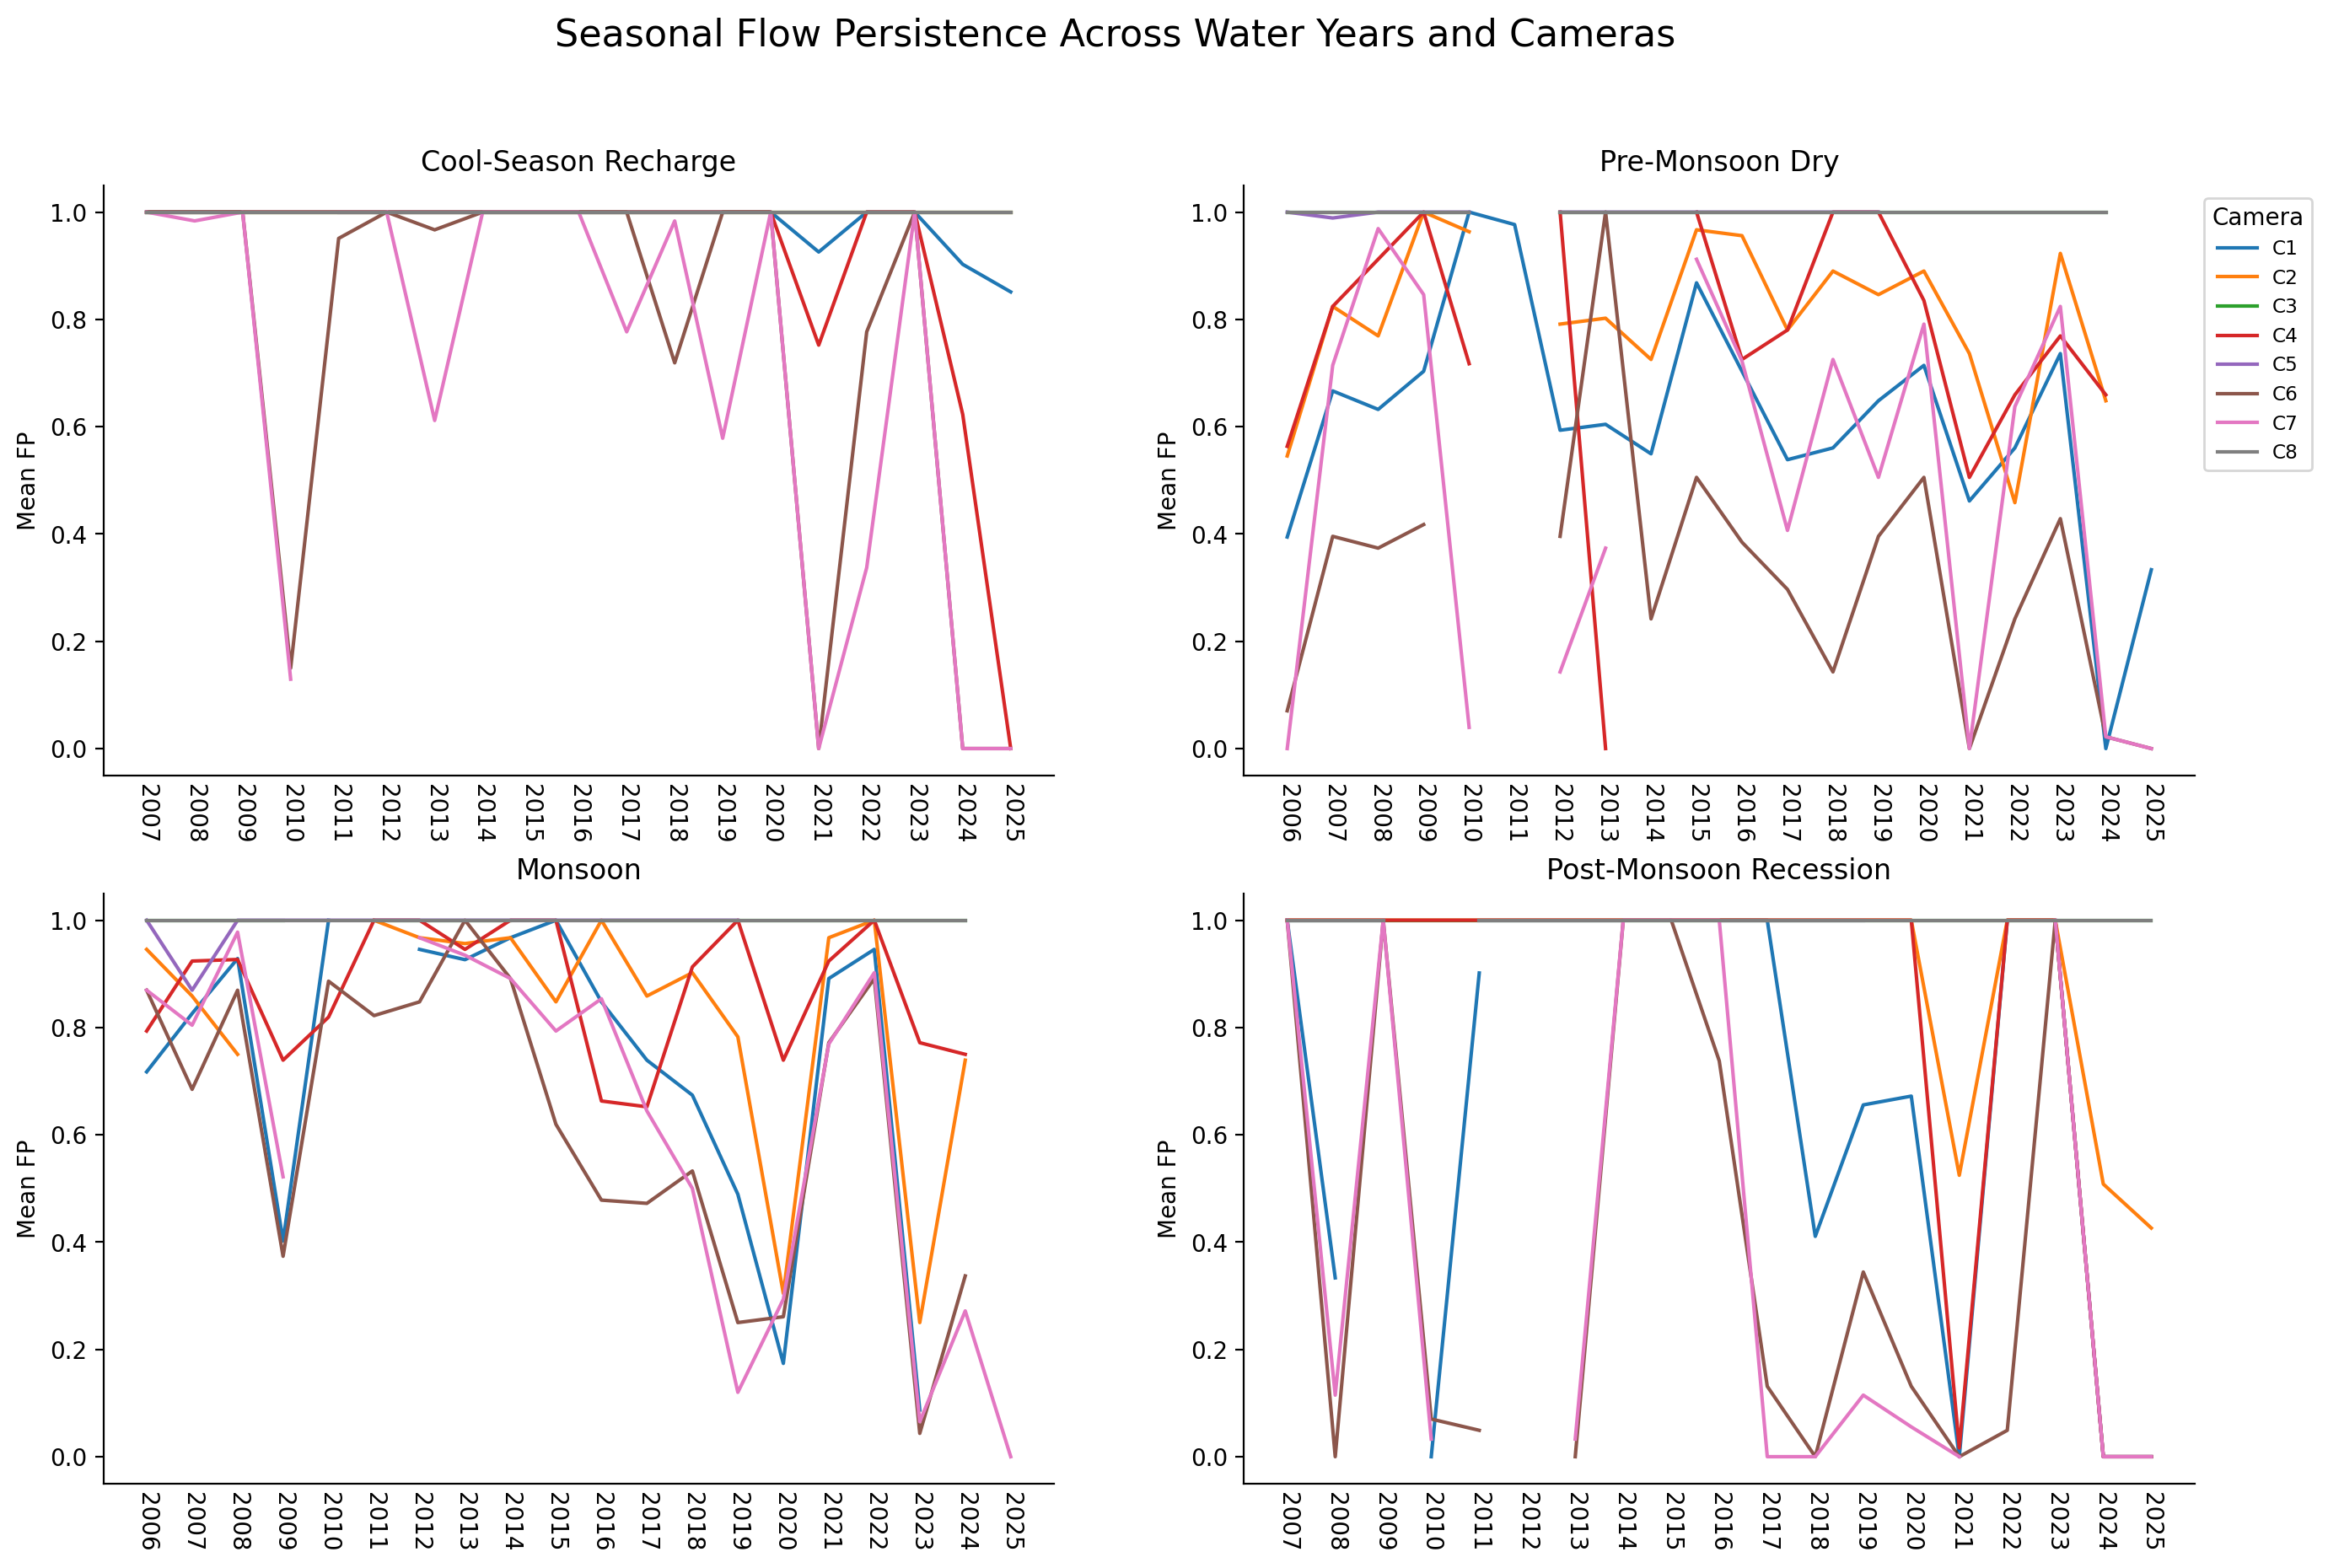

In [8]:
fig, axes = plt.subplots(2, 2, figsize = (16, 10))
ax1, ax2 = axes[0]
ax3, ax4 = axes[1]
fig.suptitle("Seasonal Flow Persistence Across Water Years and Cameras", fontsize = 16)

cool = seasons[seasons["Season"] == 1]
cool = cool[cool["WY"] != 2006].pivot(index = "WY", columns = "Camera", values = "Persistence")

for site in cool.columns:
    ax1.plot(cool.index, cool[site], label = "C" + str(site))

ax1.spines[["top", "right"]].set_visible(False)
ax1.set_title("Cool-Season Recharge")
ax1.set_ylabel("Mean FP")
ax1.set_xticks(range(2007, 2026))
ax1.tick_params(axis = "x", length = 0, labelrotation = 270)

dry = seasons[seasons["Season"] == 2].pivot(index = "WY", columns = "Camera", values = "Persistence")

for site in dry.columns:
    ax2.plot(dry.index, dry[site], label = "C" + str(site))

ax2.spines[["top", "right"]].set_visible(False)
ax2.set_title("Pre-Monsoon Dry")
ax2.set_ylabel("Mean FP")
ax2.legend(title = "Camera", loc = "lower left", bbox_to_anchor = (1, 0.5), fontsize = "small")
ax2.set_xticks(range(2006, 2026))
ax2.tick_params(axis = "x", length = 0, labelrotation = 270)

monsoon = seasons[seasons["Season"] == 3].pivot(index = "WY", columns = "Camera", values = "Persistence")

for site in monsoon.columns:
    ax3.plot(monsoon.index, monsoon[site], label = "C" + str(site))

ax3.spines[["top", "right"]].set_visible(False)
ax3.set_title("Monsoon")
ax3.set_ylabel("Mean FP")
ax3.set_xticks(range(2006, 2026))
ax3.tick_params(axis = "x", length = 0, labelrotation = 270)

recession = seasons[seasons["Season"] == 4]
recession = recession[recession["WY"] != 2006].pivot(index = "WY", columns = "Camera", values = "Persistence")

for site in recession.columns:
    ax4.plot(recession.index, recession[site], label = "C" + str(site))

ax4.spines[["top", "right"]].set_visible(False)
ax4.set_title("Post-Monsoon Recession")
ax4.set_ylabel("Mean FP")
ax4.set_xticks(range(2007, 2026))
ax4.tick_params(axis = "x", length = 0, labelrotation = 270)

%config InlineBackend.figure_format = "retina"

# plt.savefig("fp_seasons.png", format = "png", dpi = 300, bbox_inches = "tight")

C:\Users\tiffa\AppData\Local\Temp\ipykernel_7812\1148350686.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Oranges")


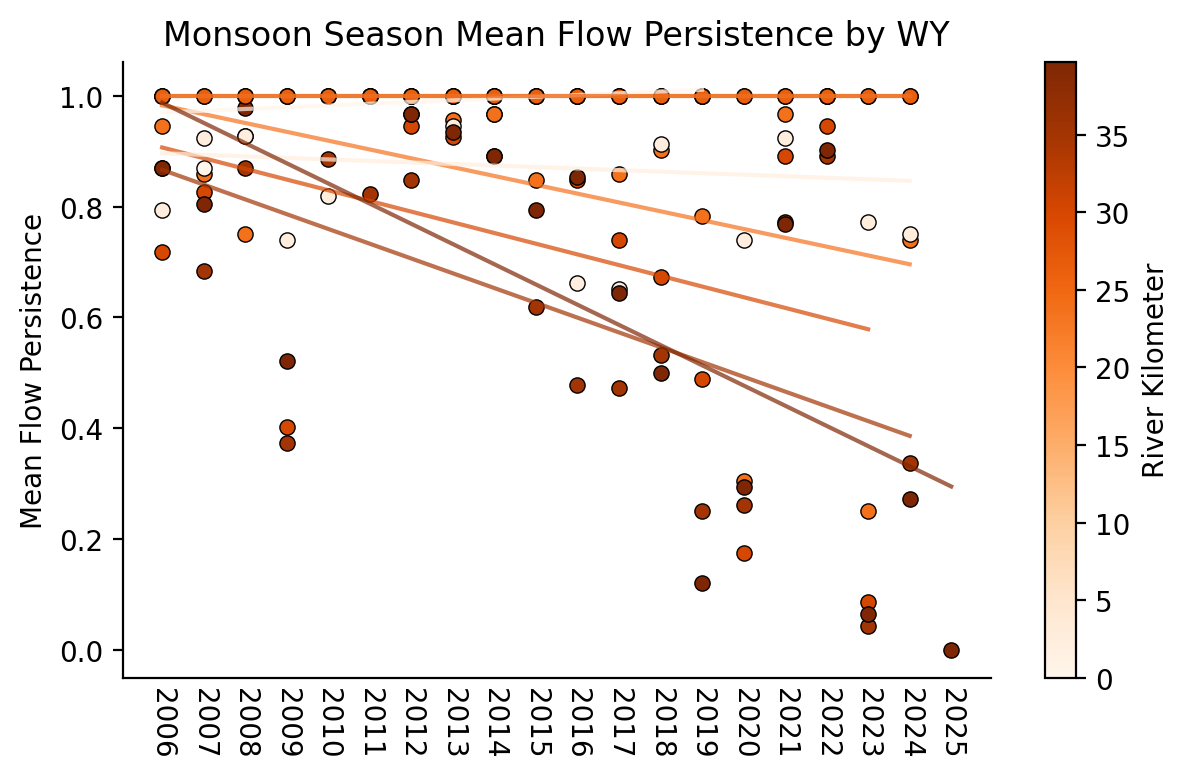

In [9]:
fig, ax = plt.subplots(figsize = (7, 4))

monsoon = seasons[seasons["Season"] == 3]

pivot = monsoon.pivot(index = "WY", columns = "Camera", values = "Persistence")

rk_lookup = monsoon.groupby("Camera")["River Kilometer"].first()

cmap = cm.get_cmap("Oranges")
norm = mcolors.Normalize(vmin = rk_lookup.min(), vmax = rk_lookup.max())

for camera in pivot.columns:
    data = pivot[camera].dropna()
    x = data.index.values
    y = data.values

    rk = rk_lookup.loc[camera]
    color = cmap(norm(rk))

    scatter = ax.scatter(x, y, s = 30, color = color, edgecolor = "black", linewidth = 0.5)

    slope, intercept, _, _, _ = linregress(x, y)
    fit = intercept + slope * x
    ax.plot(x, fit, color = color, alpha = 0.7)

ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Monsoon Season Mean Flow Persistence by WY")
ax.set_ylabel("Mean Flow Persistence")
ax.set_xticks(range(2006, 2026))
ax.tick_params(axis = "x", length = 0, labelrotation = 270)

sm = cm.ScalarMappable(norm = norm, cmap = cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax = ax, label = "River Kilometer")
# cbar.ax.yaxis.set_label_position("left")

%config InlineBackend.figure_format = "retina"

# plt.savefig("monsoon_fp_rk_lm.png", format = "png", dpi = 300, bbox_inches = "tight")

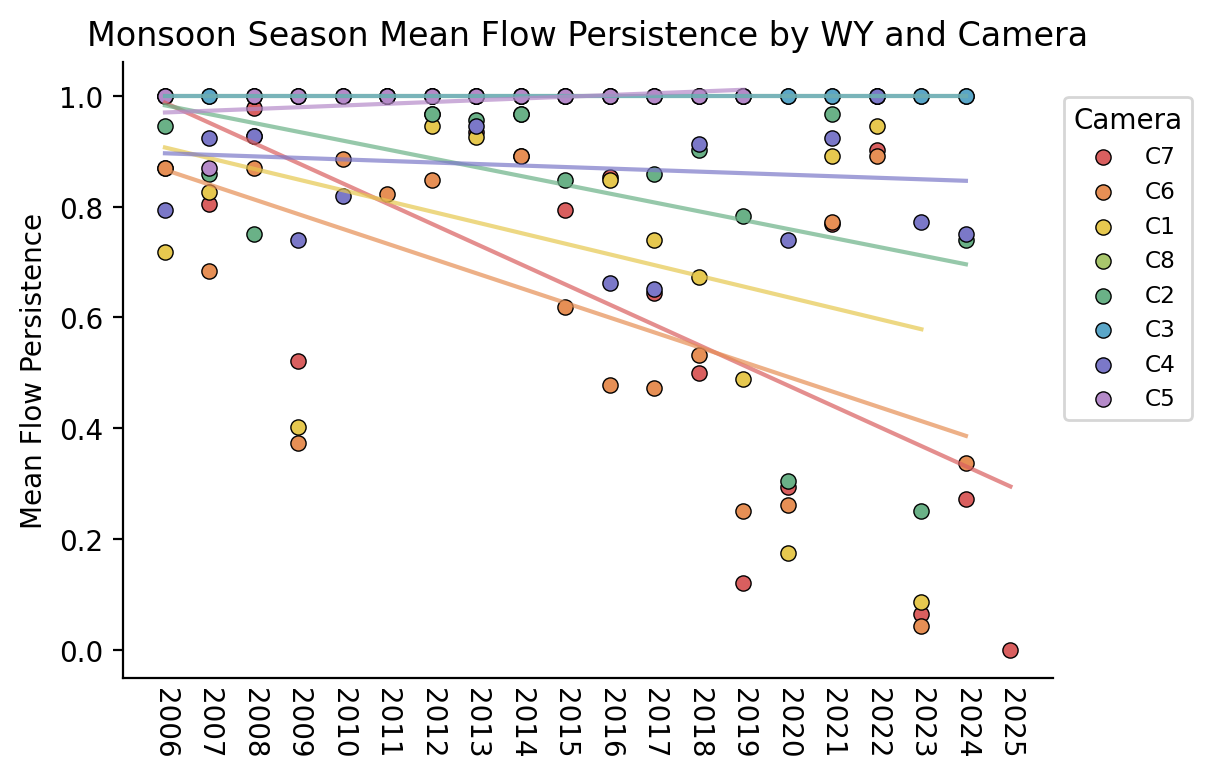

In [10]:
fig, ax = plt.subplots(figsize = (6, 4))

monsoon = seasons[seasons["Season"] == 3]

pivot = monsoon.pivot(index = "WY", columns = "Camera", values = "Persistence")

order = [s for s in names.values() if s in pivot.columns]
pivot = pivot.reindex(columns = order)

colors = ListedColormap([
    "#d95f5f",
    "#e68f55",
    "#e6c84f",
    "#a8c66c",
    "#6ab187",
    "#5aa6c8",
    "#7b78c8",
    "#b58ac9",
    ]).colors

for i, camera in enumerate(pivot.columns):
    data = pivot[camera].dropna()
    x = data.index.values
    y = data.values

    scatter = ax.scatter(x, y, color = colors[i], label = "C" + str(camera), s = 30, edgecolor = "black", linewidth = 0.5)

    slope, intercept, _, _, _ = linregress(x, y)
    fit = intercept + slope * x
    ax.plot(x, fit, color = colors[i], alpha = 0.7)

ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Monsoon Season Mean Flow Persistence by WY and Camera")
ax.set_ylabel("Mean Flow Persistence")
ax.legend(title = "Camera", loc = "lower left", bbox_to_anchor = (1, 0.4), fontsize = "small")
ax.set_xticks(range(2006, 2026))
ax.tick_params(axis = "x", length = 0, labelrotation = 270)

%config InlineBackend.figure_format = "retina"

# plt.savefig("monsoon_fp_lm_cat.png", format = "png", dpi = 300, bbox_inches = "tight")

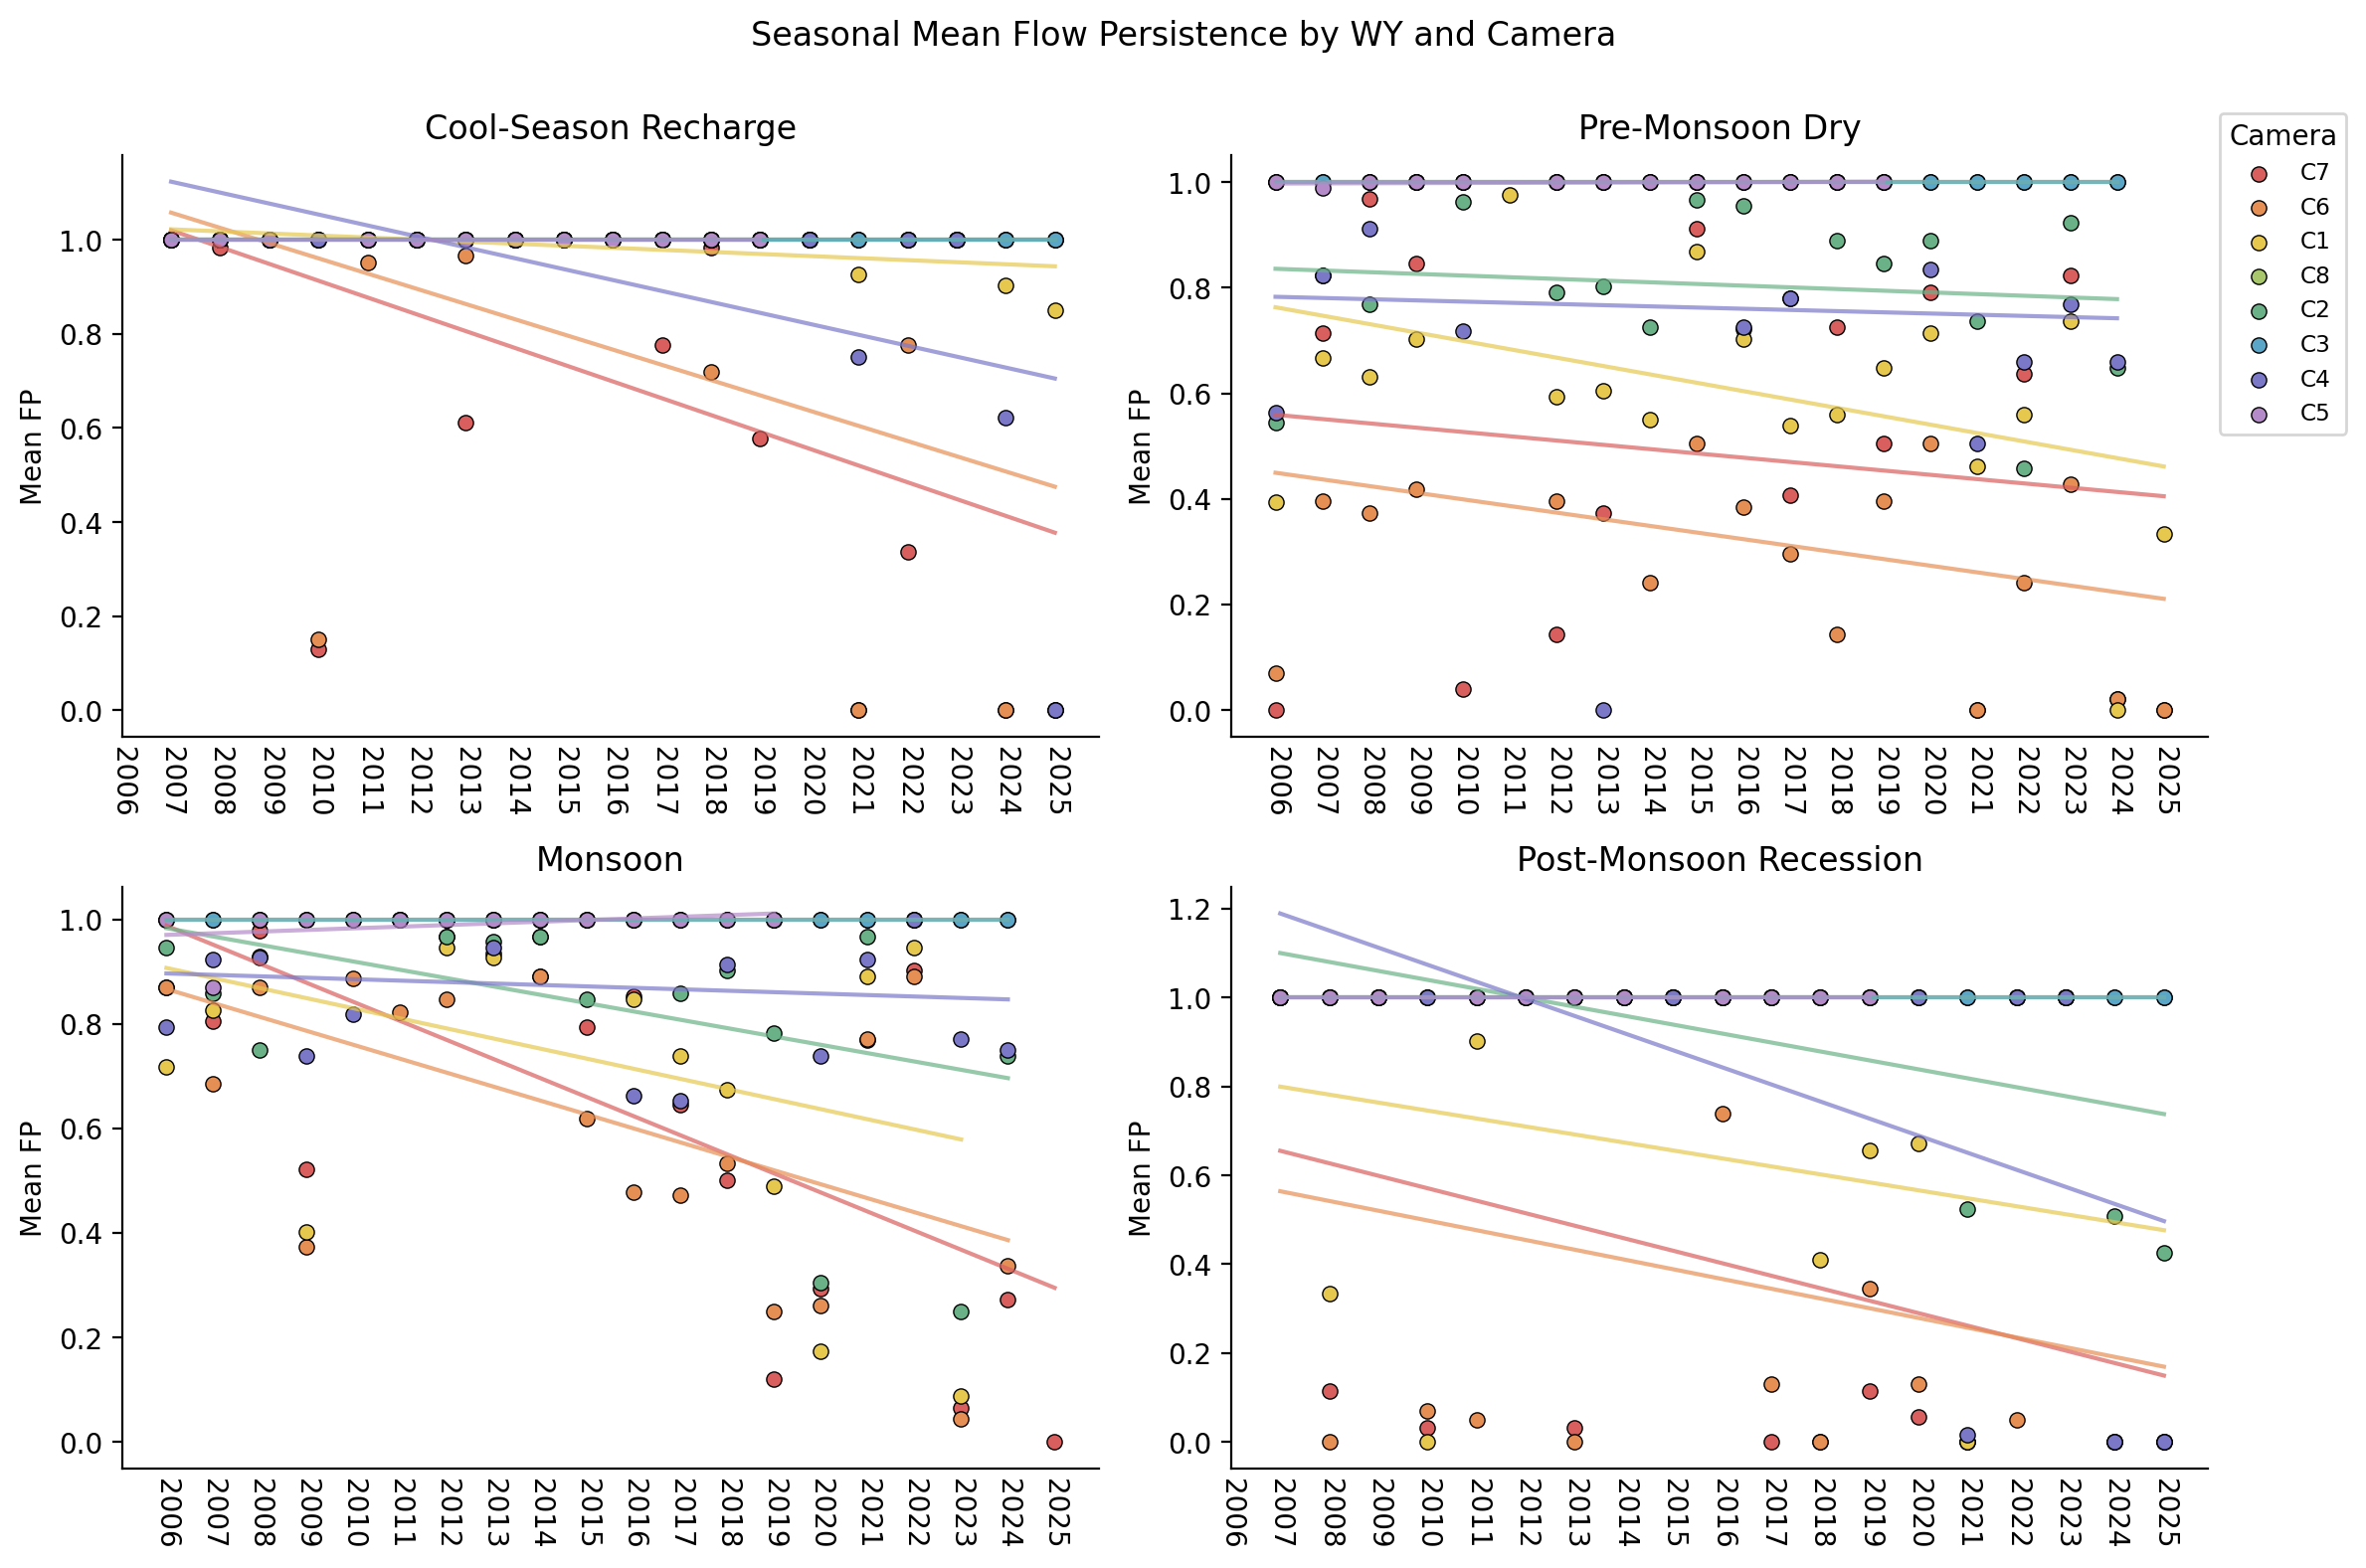

In [14]:
fig, axes = plt.subplots(2, 2, figsize = (12, 8))
(ax1, ax2), (ax3, ax4) = axes

fig.suptitle("Seasonal Mean Flow Persistence by WY and Camera")

season_titles = {
    1: "Cool-Season Recharge",
    2: "Pre-Monsoon Dry",
    3: "Monsoon",
    4: "Post-Monsoon Recession"
}

colors = ListedColormap([
    "#d95f5f",
    "#e68f55",
    "#e6c84f",
    "#a8c66c",
    "#6ab187",
    "#5aa6c8",
    "#7b78c8",
    "#b58ac9",
]).colors

axes_map = {1: ax1, 2: ax2, 3: ax3, 4: ax4}

for season_id, ax in axes_map.items():
    df = seasons[seasons["Season"] == season_id]
    if season_id in [1, 4]:
        df = df[df["WY"] != 2006]
    pivot = df.pivot(index="WY", columns="Camera", values="Persistence")
    order = [s for s in names.values() if s in pivot.columns]
    pivot = pivot.reindex(columns=order)
    for i, camera in enumerate(pivot.columns):
        data = pivot[camera].dropna()
        x = data.index.values
        y = data.values
        ax.scatter(
            x, y,
            color = colors[i],
            label = "C" + str(camera),
            s = 30,
            edgecolor="black",
            linewidth=0.5
        )
        slope, intercept, _, _, _ = linregress(x, y)
        fit = intercept + slope * x
        ax.plot(x, fit, color=colors[i], alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(season_titles[season_id])
    ax.set_ylabel("Mean FP")
    ax.set_xticks(range(2006, 2026))
    ax.tick_params(axis="x", length=0, labelrotation=270)
ax2.legend(
    title = "Camera",
    loc = "lower left",
    bbox_to_anchor = (1, 0.5),
    fontsize="small"
)

plt.tight_layout()

%config InlineBackend.figure_format = "retina"

plt.savefig("seasonal_fp_lm_cat.png", format = "png", dpi = 300, bbox_inches = "tight")

In [12]:
daymet = pd.read_csv("Daymet2006_2024.csv")
daymet["camera"] = daymet["site"].map(names).astype("Int64")
daymet["date"] = pd.to_datetime(daymet["date"])
daymet["month"] = daymet["date"].dt.month
daymet["season"] = daymet["month"].apply(season)
daymet["wy"] = daymet["date"].apply(water_year)
daymet["temp"] = (daymet["tmax"] + daymet["tmin"]) / 2
daymet.head()

,year,yday,dayl,prcp,srad,swe,tmax,tmin,vp,x,y,site,camera,date,tvpd,month,season,wy,temp
0,2006,1,35898.23,0.0,300.80,0.0,21.07,2.42,256.59,-110.185152,31.689704,Boquillas,8,2006-01-01,1.355837,1,1,2006,11.745
1,2006,2,35927.62,0.0,321.79,0.0,24.39,3.32,274.61,-110.185152,31.689704,Boquillas,8,2006-01-02,1.640207,1,1,2006,13.855
2,2006,3,35959.43,0.0,283.70,0.0,21.02,4.10,291.27,-110.185152,31.689704,Boquillas,8,2006-01-03,1.363263,1,1,2006,12.560
3,2006,4,35993.63,0.0,345.25,0.0,22.21,-1.78,185.24,-110.185152,31.689704,Boquillas,8,2006-01-04,1.421772,1,1,2006,10.215
4,2006,5,36030.20,0.0,320.43,0.0,21.01,0.60,223.18,-110.185152,31.689704,Boquillas,8,2006-01-05,1.340083,1,1,2006,10.805


In [13]:
precip_seasons = daymet.dropna(subset = ["prcp"]).groupby(["camera", "wy", "season"])["prcp"].sum().reset_index()
precip_seasons.head()

,camera,wy,season,prcp
0,1,2006,1,6.11
1,1,2006,2,8.03
2,1,2006,3,254.84
3,1,2007,1,63.98
4,1,2007,2,19.49


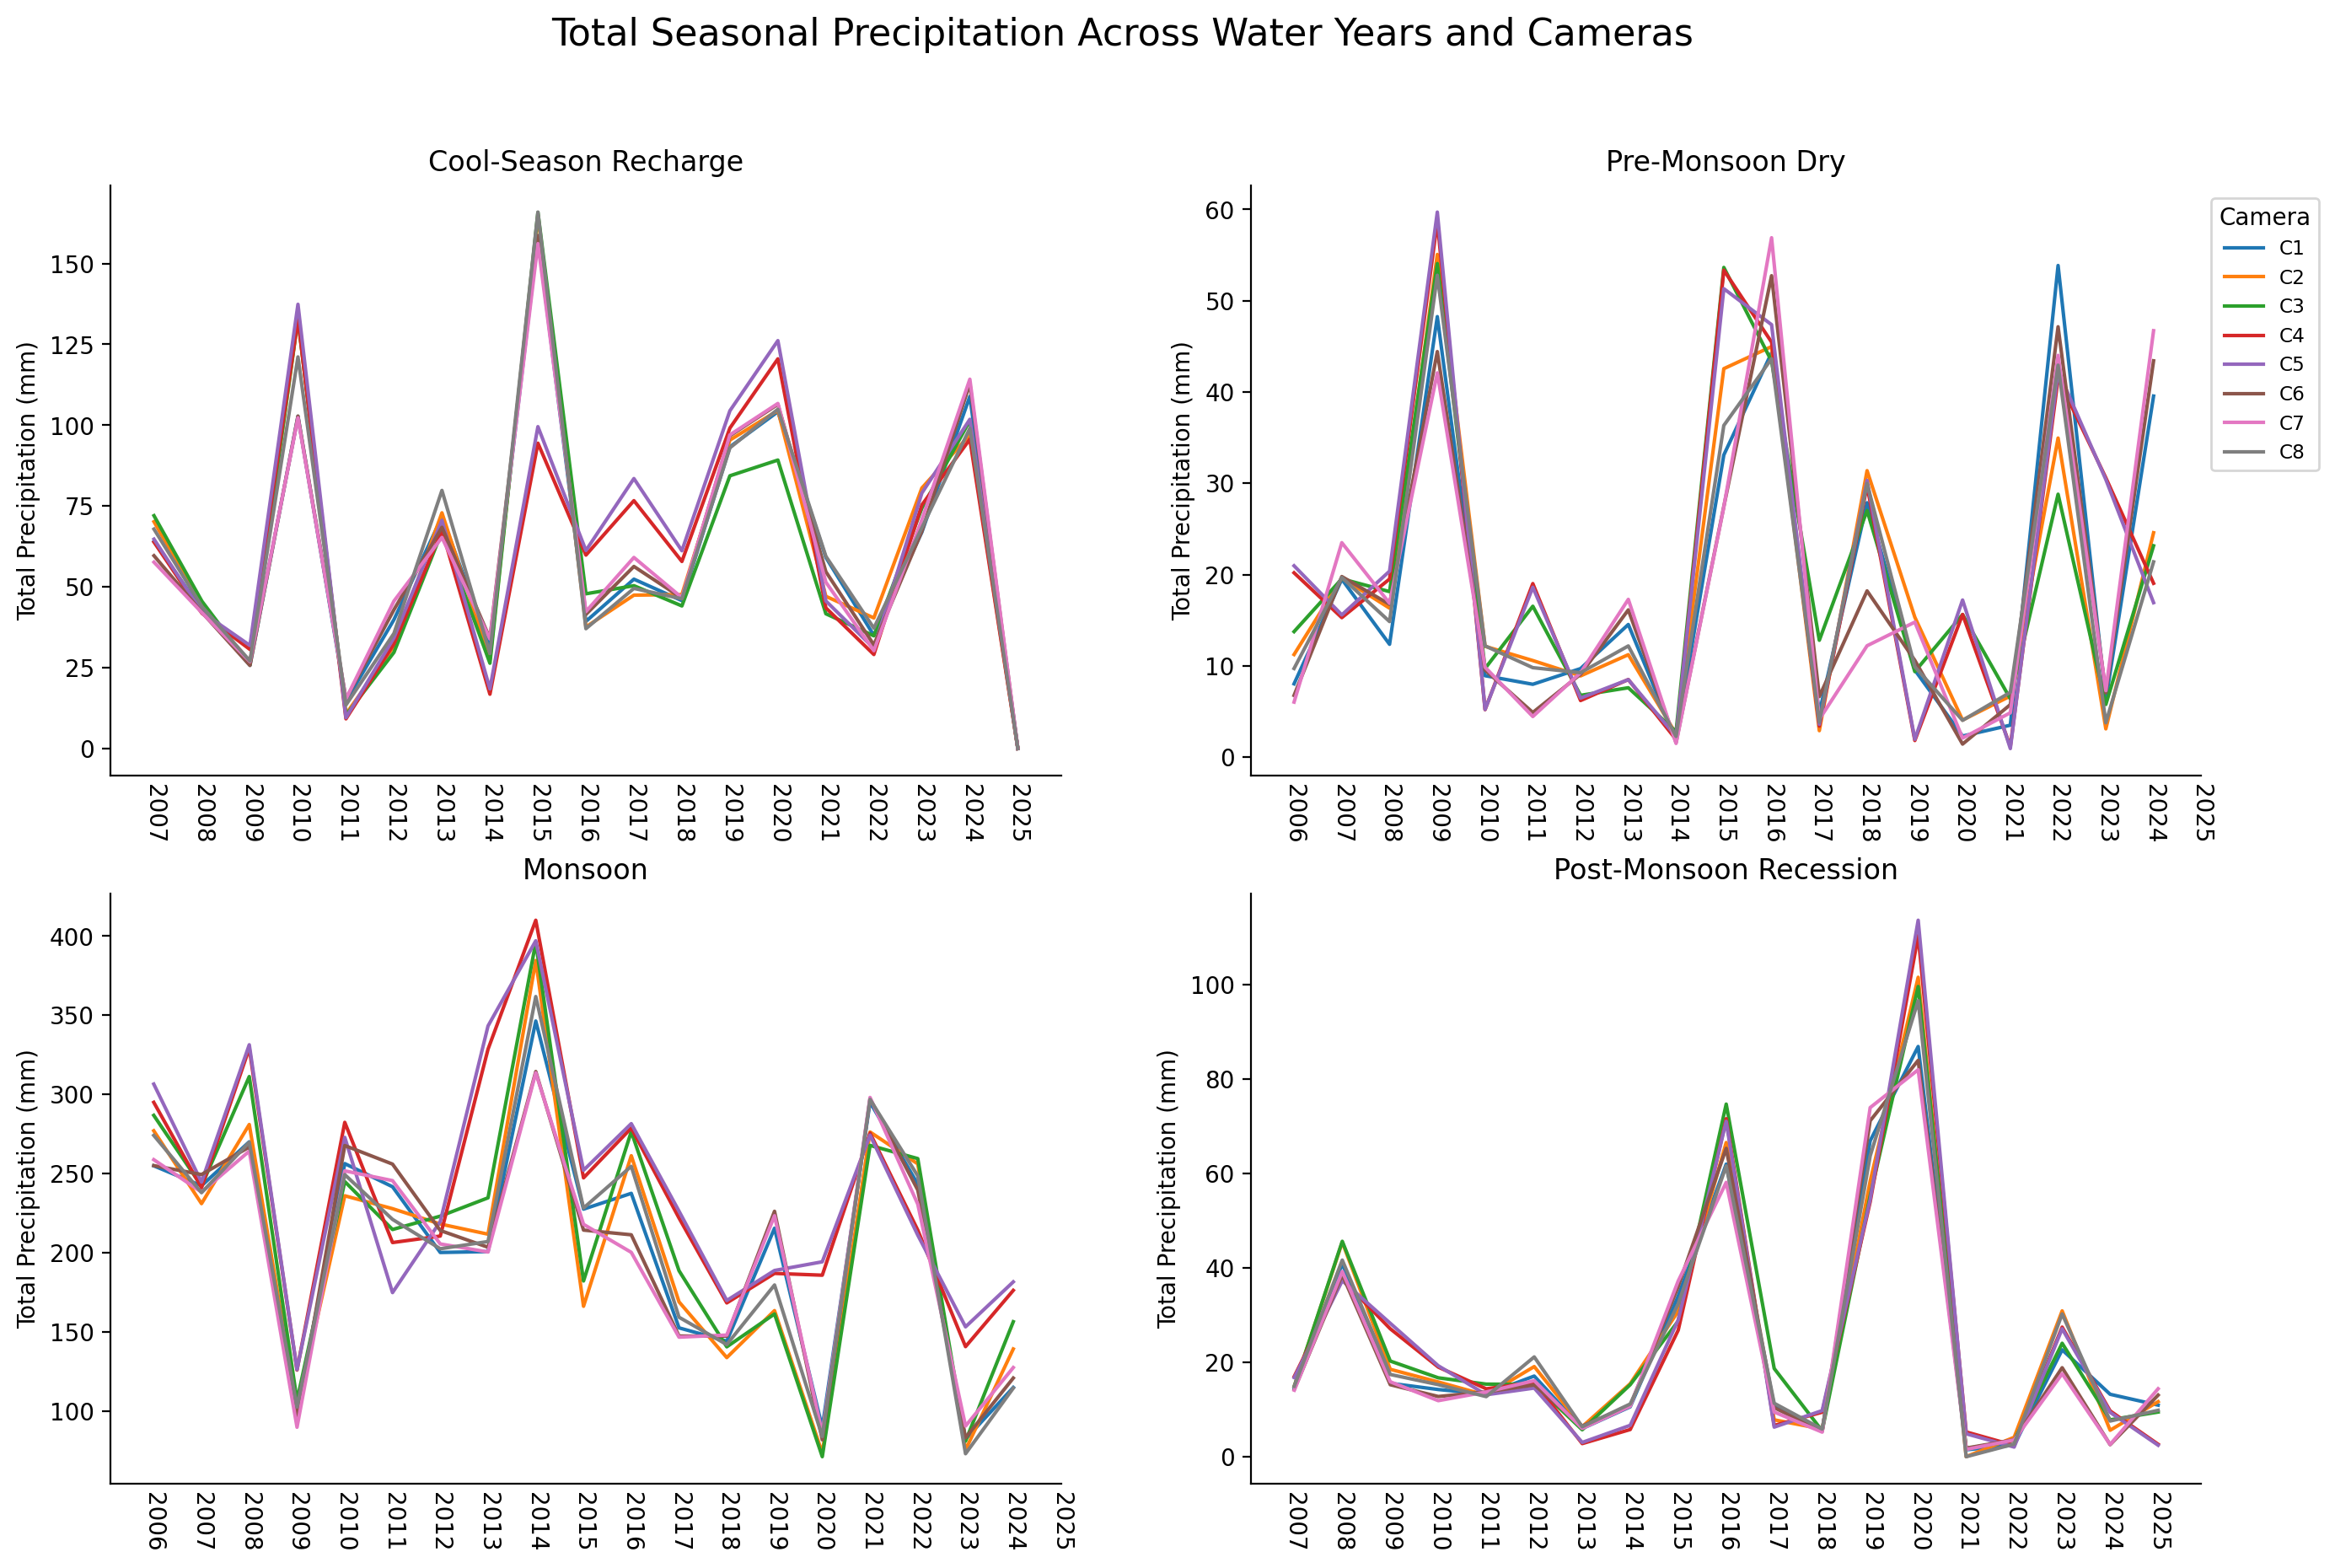

In [14]:
fig, axes = plt.subplots(2, 2, figsize = (16, 10))
ax1, ax2 = axes[0]
ax3, ax4 = axes[1]
fig.suptitle("Total Seasonal Precipitation Across Water Years and Cameras", fontsize = 16)

cool = precip_seasons[precip_seasons["season"] == 1]
cool = cool[cool["wy"] != 2006].pivot(index = "wy", columns = "camera", values = "prcp")

for site in cool.columns:
    ax1.plot(cool.index, cool[site], label = "C" + str(site))

ax1.spines[["top", "right"]].set_visible(False)
ax1.set_title("Cool-Season Recharge")
ax1.set_ylabel("Total Precipitation (mm)")
ax1.set_xticks(range(2007, 2026))
ax1.tick_params(axis = "x", length = 0, labelrotation = 270)

dry = precip_seasons[precip_seasons["season"] == 2].pivot(index = "wy", columns = "camera", values = "prcp")

for site in dry.columns:
    ax2.plot(dry.index, dry[site], label = "C" + str(site))

ax2.spines[["top", "right"]].set_visible(False)
ax2.set_title("Pre-Monsoon Dry")
ax2.set_ylabel("Total Precipitation (mm)")
ax2.legend(title = "Camera", loc = "lower left", bbox_to_anchor = (1, 0.5), fontsize = "small")
ax2.set_xticks(range(2006, 2026))
ax2.tick_params(axis = "x", length = 0, labelrotation = 270)

monsoon = precip_seasons[precip_seasons["season"] == 3].pivot(index = "wy", columns = "camera", values = "prcp")

for site in monsoon.columns:
    ax3.plot(monsoon.index, monsoon[site], label = "C" + str(site))

ax3.spines[["top", "right"]].set_visible(False)
ax3.set_title("Monsoon")
ax3.set_ylabel("Total Precipitation (mm)")
ax3.set_xticks(range(2006, 2026))
ax3.tick_params(axis = "x", length = 0, labelrotation = 270)

recession = precip_seasons[precip_seasons["season"] == 4]
recession = recession[recession["wy"] != 2006].pivot(index = "wy", columns = "camera", values = "prcp")

for site in recession.columns:
    ax4.plot(recession.index, recession[site], label = "C" + str(site))

ax4.spines[["top", "right"]].set_visible(False)
ax4.set_title("Post-Monsoon Recession")
ax4.set_ylabel("Total Precipitation (mm)")
ax4.set_xticks(range(2007, 2026))
ax4.tick_params(axis = "x", length = 0, labelrotation = 270)

%config InlineBackend.figure_format = "retina"

# plt.savefig("precip_seasons.png", format = "png", dpi = 300, bbox_inches = "tight")

In [15]:
temp_seasons = daymet.dropna(subset = ["temp"]).groupby(["camera", "wy", "season"])["temp"].mean().reset_index()
temp_seasons.head()

,camera,wy,season,temp
0,1,2006,1,10.986944
1,1,2006,2,22.472363
2,1,2006,3,24.694674
3,1,2007,1,9.340248
4,1,2007,2,21.550000


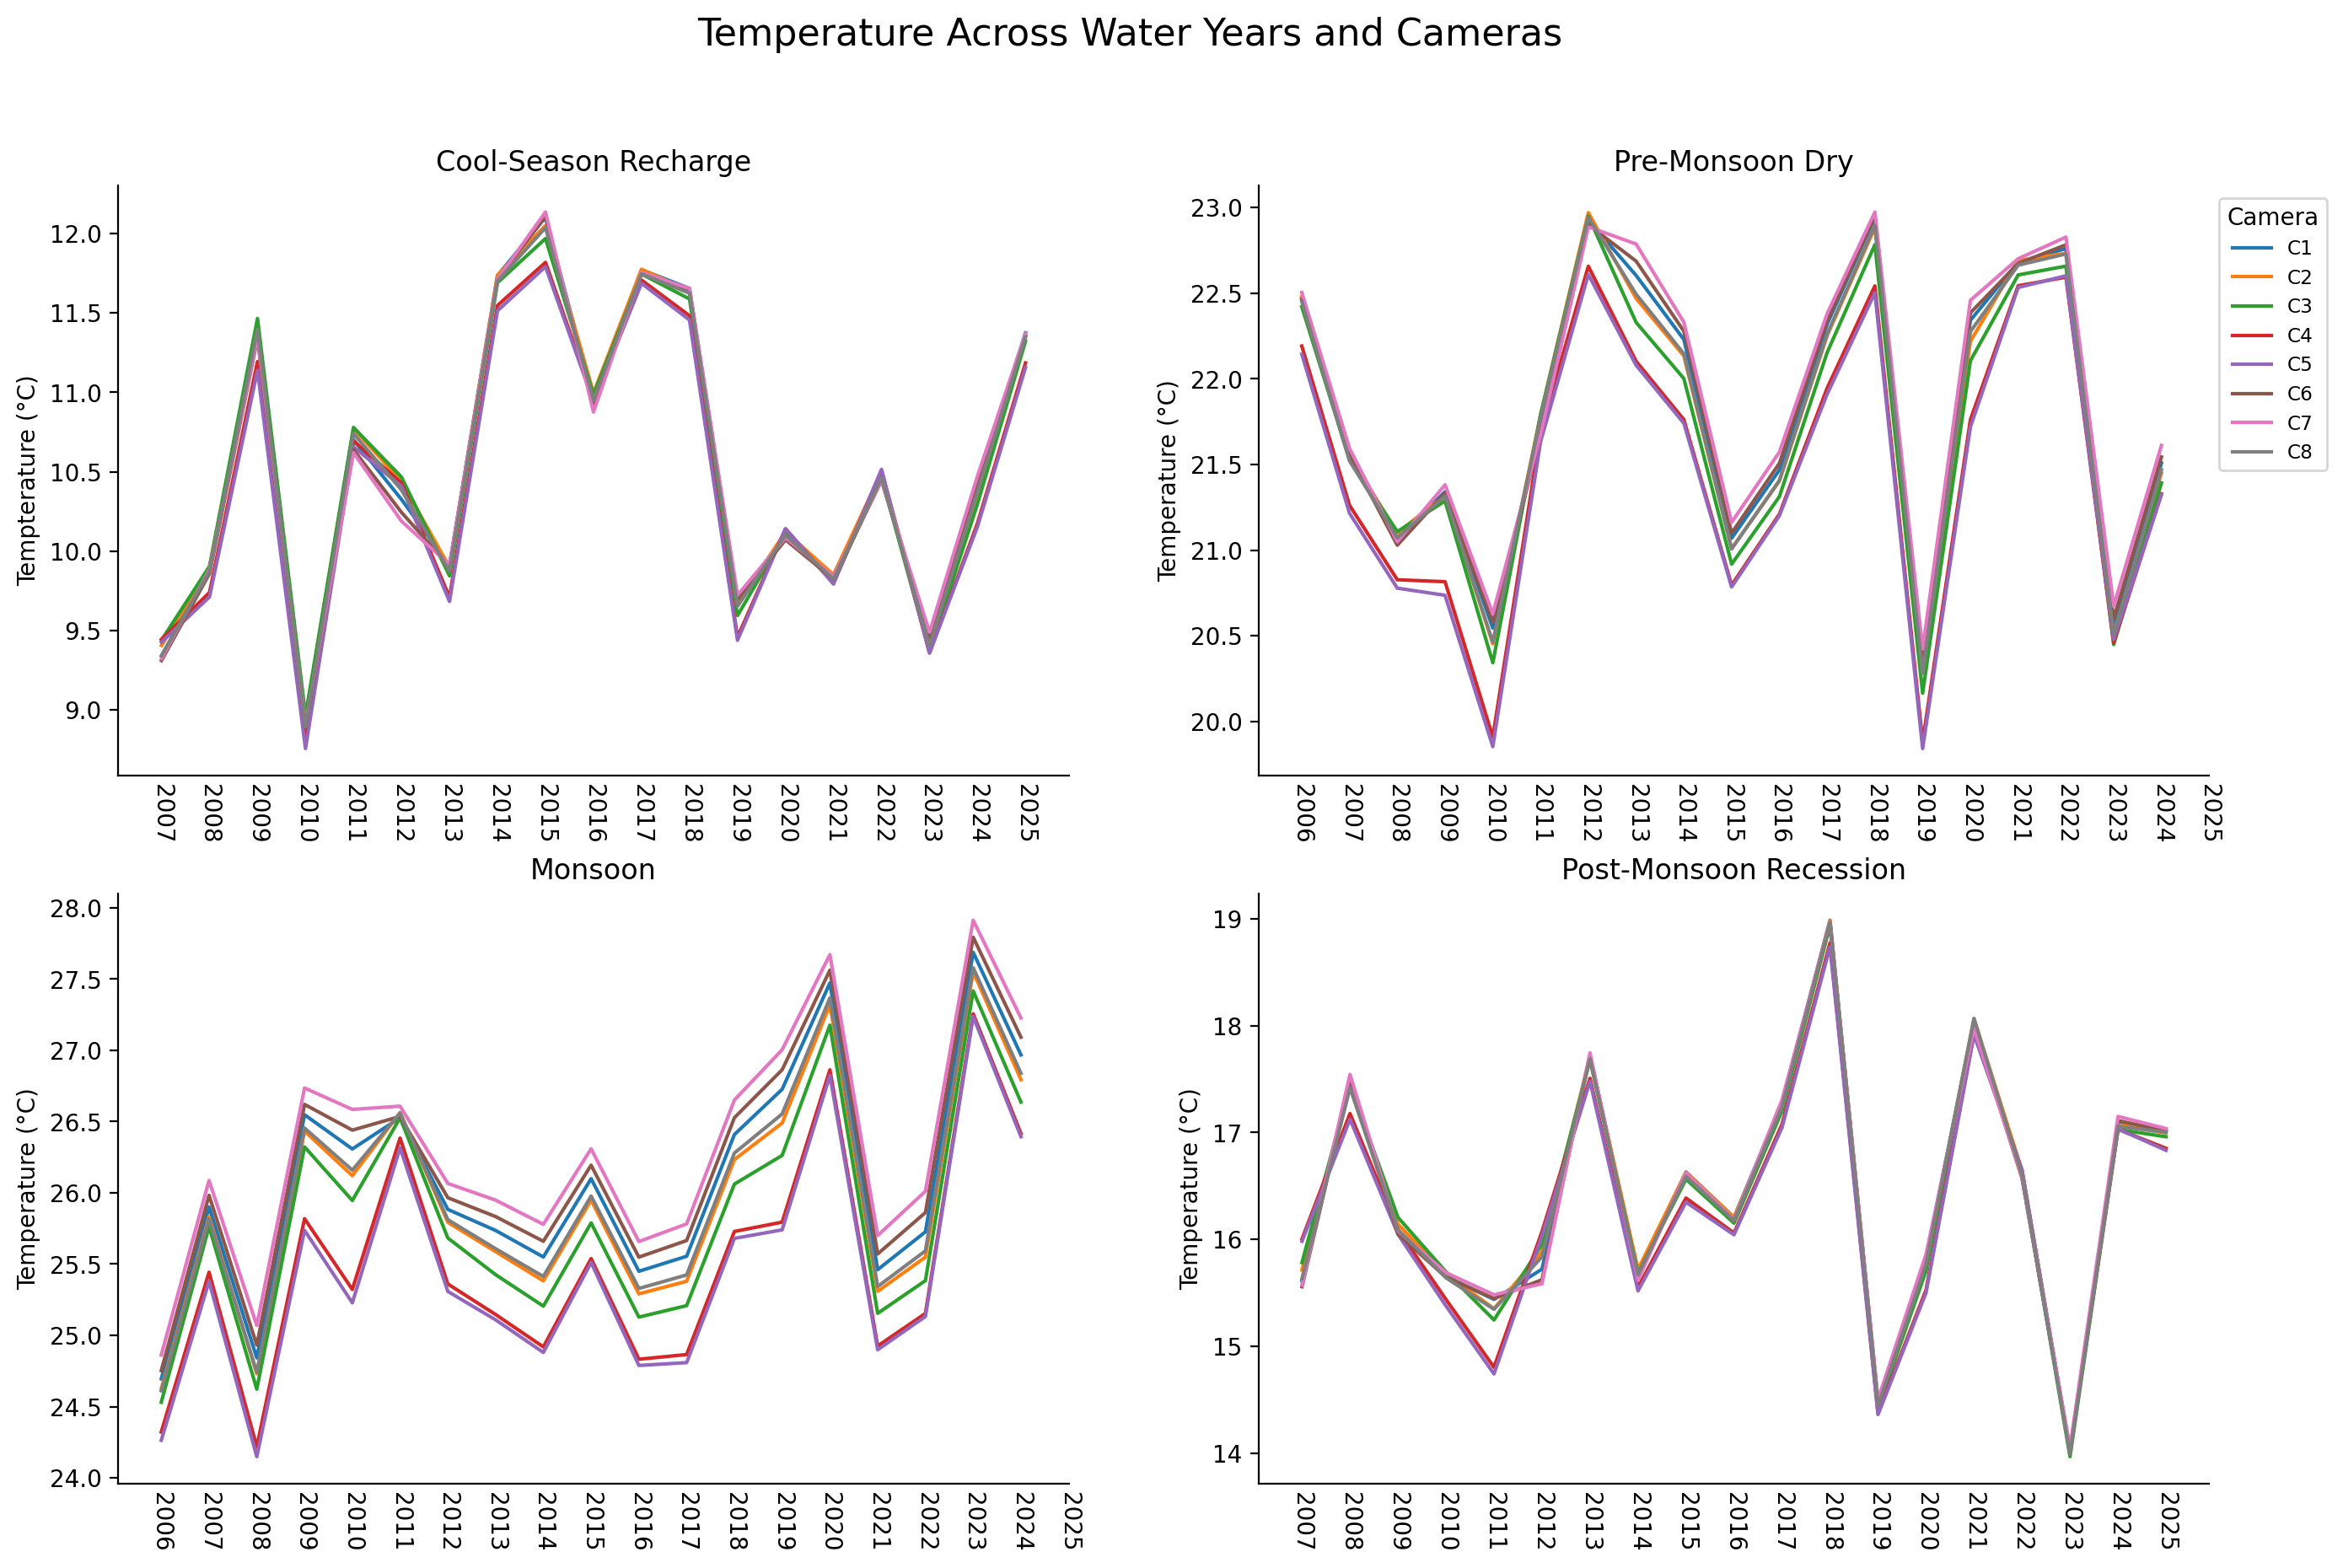

In [16]:
fig, axes = plt.subplots(2, 2, figsize = (16, 10))
ax1, ax2 = axes[0]
ax3, ax4 = axes[1]
fig.suptitle("Temperature Across Water Years and Cameras", fontsize = 16)

cool = temp_seasons[temp_seasons["season"] == 1]
cool = cool[cool["wy"] != 2006].pivot(index = "wy", columns = "camera", values = "temp")

for site in cool.columns:
    ax1.plot(cool.index, cool[site], label = "C" + str(site))

ax1.spines[["top", "right"]].set_visible(False)
ax1.set_title("Cool-Season Recharge")
ax1.set_ylabel("Tempterature (°C)")
ax1.set_xticks(range(2007, 2026))
ax1.tick_params(axis = "x", length = 0, labelrotation = 270)

dry = temp_seasons[temp_seasons["season"] == 2].pivot(index = "wy", columns = "camera", values = "temp")
for site in dry.columns:
    ax2.plot(dry.index, dry[site], label = "C" + str(site))

ax2.spines[["top", "right"]].set_visible(False)
ax2.set_title("Pre-Monsoon Dry")
ax2.set_ylabel("Temperature (°C)")
ax2.legend(title = "Camera", loc = "lower left", bbox_to_anchor = (1, 0.5), fontsize = "small")
ax2.set_xticks(range(2006, 2026))
ax2.tick_params(axis = "x", length = 0, labelrotation = 270)

monsoon = temp_seasons[temp_seasons["season"] == 3].pivot(index = "wy", columns = "camera", values = "temp")

for site in monsoon.columns:
    ax3.plot(monsoon.index, monsoon[site], label = "C" + str(site))

ax3.spines[["top", "right"]].set_visible(False)
ax3.set_title("Monsoon")
ax3.set_ylabel("Temperature (°C)")
ax3.set_xticks(range(2006, 2026))
ax3.tick_params(axis = "x", length = 0, labelrotation = 270)

recession = temp_seasons[temp_seasons["season"] == 4]
recession = recession[recession["wy"] != 2006].pivot(index = "wy", columns = "camera", values = "temp")

for site in recession.columns:
    ax4.plot(recession.index, recession[site], label = "C" + str(site))

ax4.spines[["top", "right"]].set_visible(False)
ax4.set_title("Post-Monsoon Recession")
ax4.set_ylabel("Temperature (°C)")
ax4.set_xticks(range(2007, 2026))
ax4.tick_params(axis = "x", length = 0, labelrotation = 270)

%config InlineBackend.figure_format = "retina"

# plt.savefig("temp_seasons.png", format = "png", dpi = 300, bbox_inches = "tight")

In [17]:
tvpd_seasons = daymet.dropna(subset = ["tvpd"]).groupby(["camera", "wy", "season"])["tvpd"].mean().reset_index()
tvpd_seasons.head()

,camera,wy,season,tvpd
0,1,2006,1,1.347442
1,1,2006,2,2.694566
2,1,2006,3,1.902486
3,1,2007,1,0.991667
4,1,2007,2,2.518652


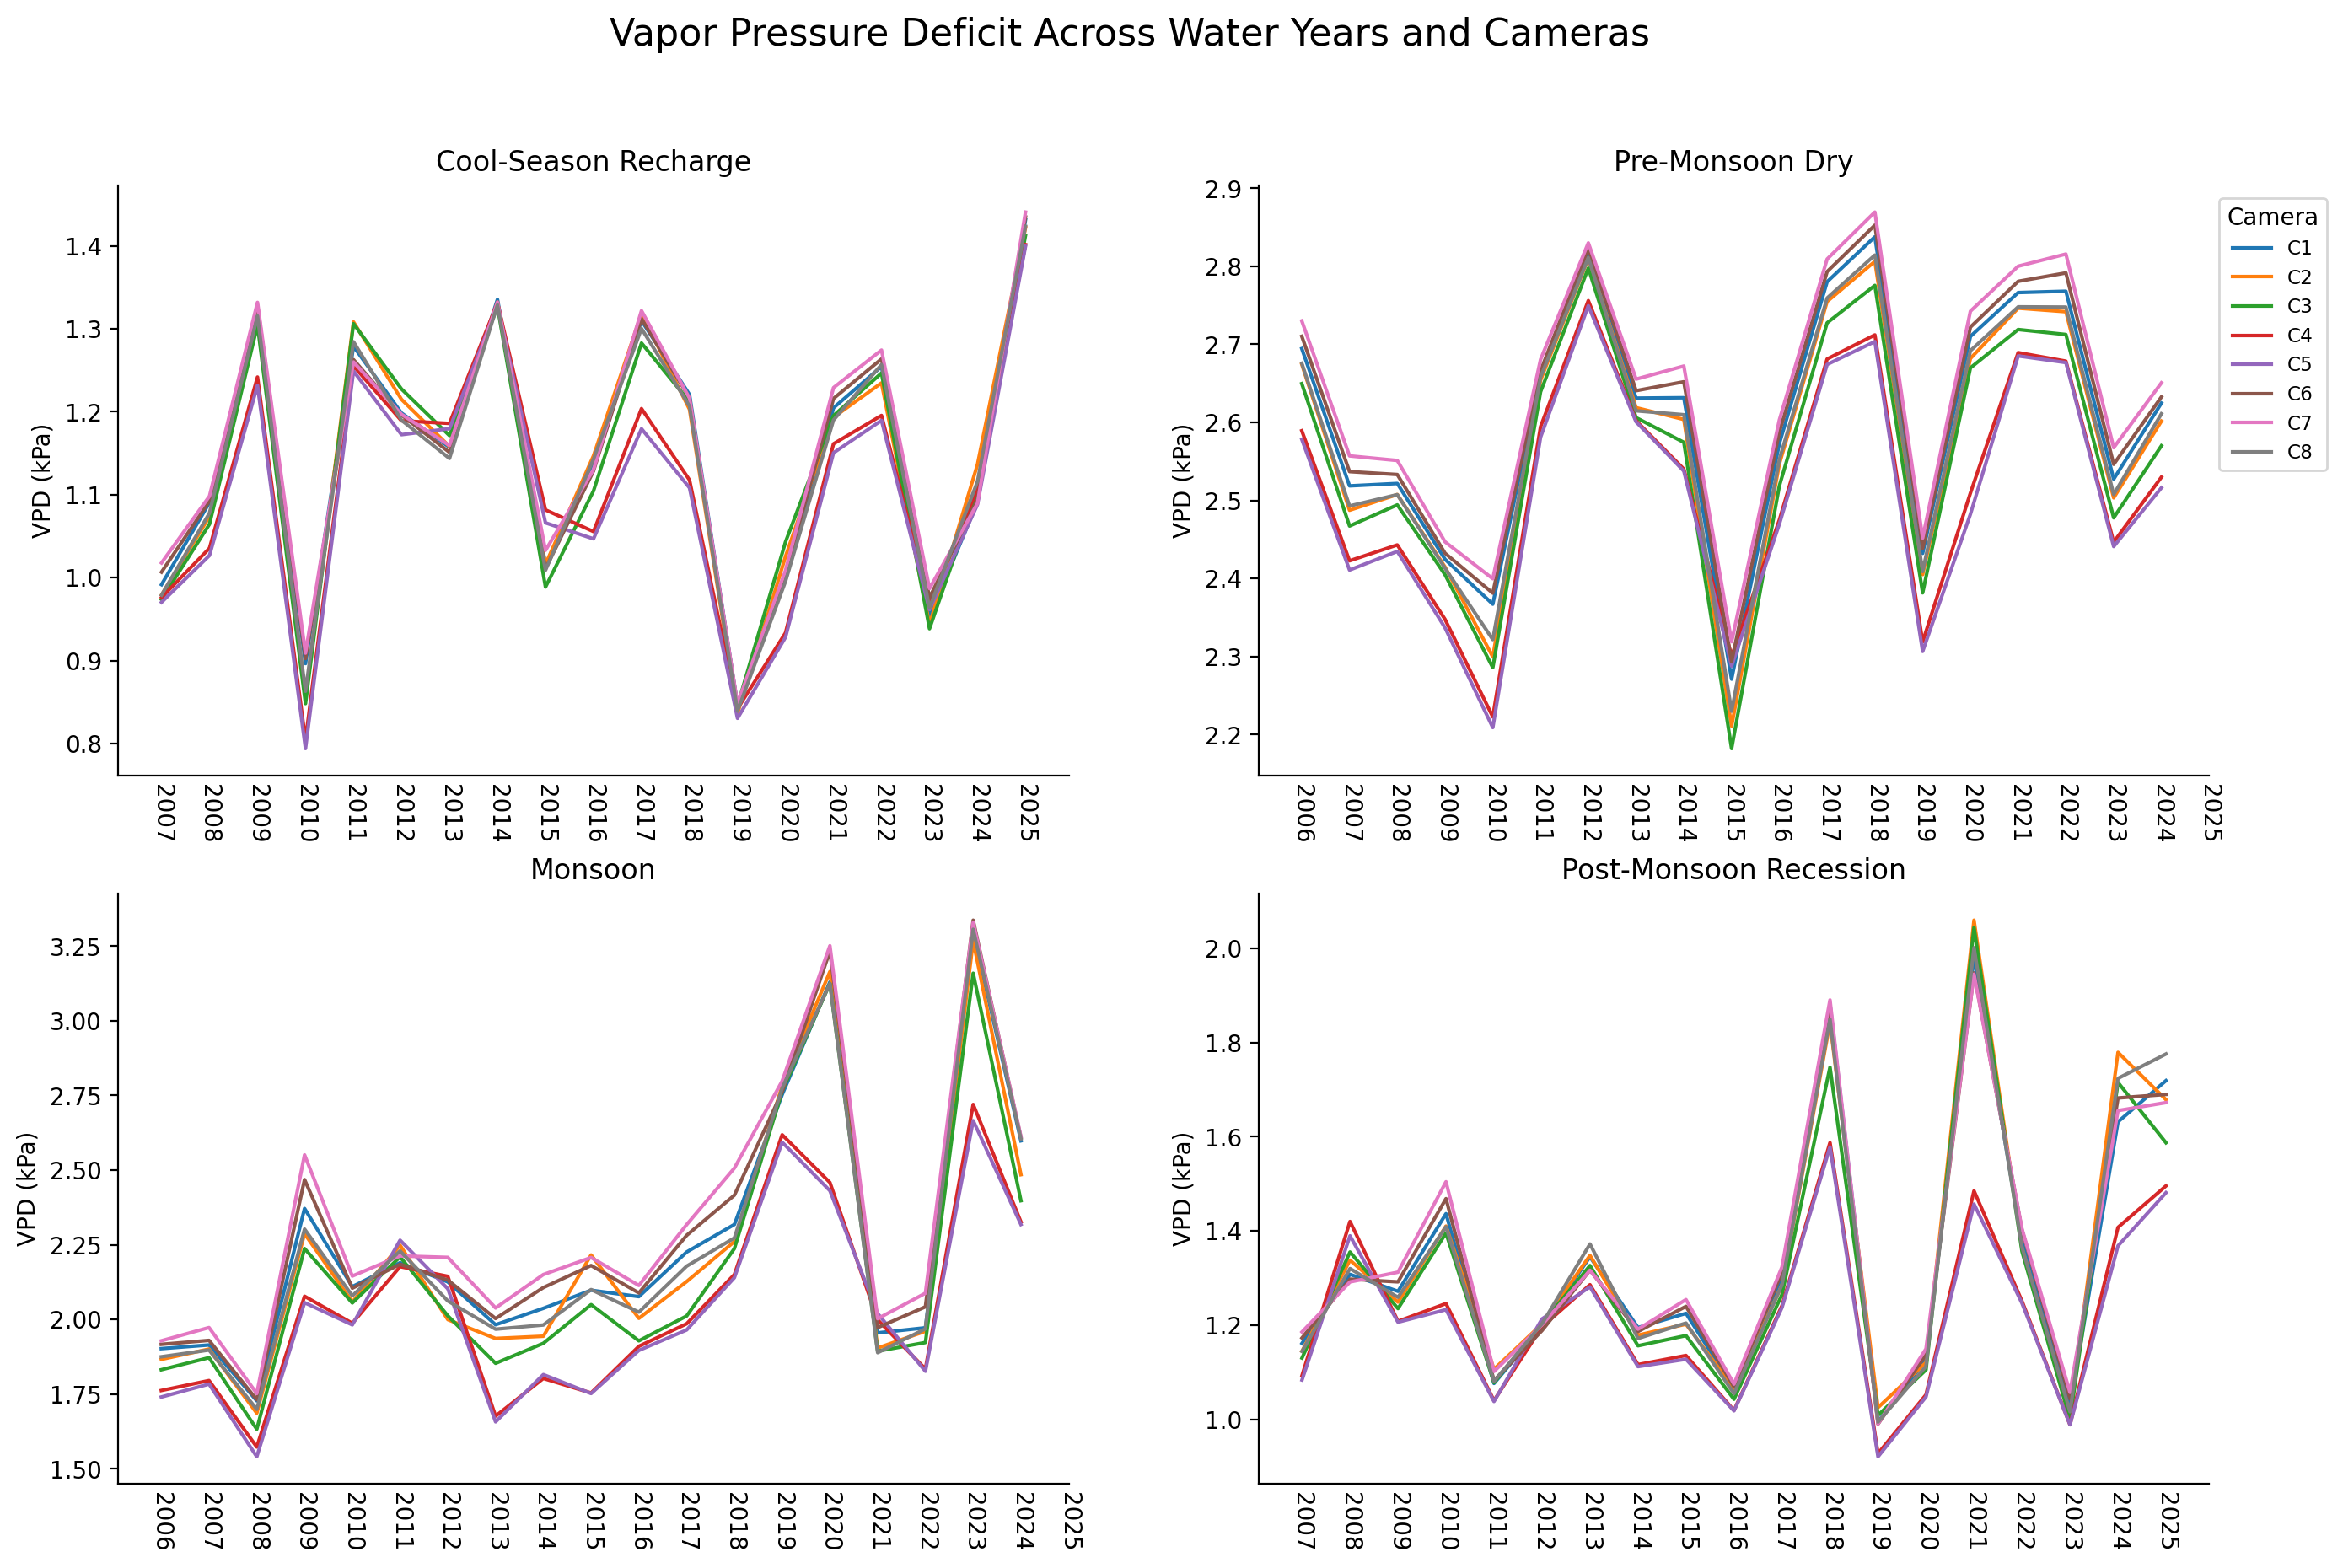

In [18]:
fig, axes = plt.subplots(2, 2, figsize = (16, 10))
ax1, ax2 = axes[0]
ax3, ax4 = axes[1]
fig.suptitle("Vapor Pressure Deficit Across Water Years and Cameras", fontsize = 16)

cool = tvpd_seasons[tvpd_seasons["season"] == 1]
cool = cool[cool["wy"] != 2006].pivot(index = "wy", columns = "camera", values = "tvpd")

for site in cool.columns:
    ax1.plot(cool.index, cool[site], label = "C" + str(site))

ax1.spines[["top", "right"]].set_visible(False)
ax1.set_title("Cool-Season Recharge")
ax1.set_ylabel("VPD (kPa)")
ax1.set_xticks(range(2007, 2026))
ax1.tick_params(axis = "x", length = 0, labelrotation = 270)

dry = tvpd_seasons[tvpd_seasons["season"] == 2].pivot(index = "wy", columns = "camera", values = "tvpd")
for site in dry.columns:
    ax2.plot(dry.index, dry[site], label = "C" + str(site))

ax2.spines[["top", "right"]].set_visible(False)
ax2.set_title("Pre-Monsoon Dry")
ax2.set_ylabel("VPD (kPa)")
ax2.legend(title = "Camera", loc = "lower left", bbox_to_anchor = (1, 0.5), fontsize = "small")
ax2.set_xticks(range(2006, 2026))
ax2.tick_params(axis = "x", length = 0, labelrotation = 270)

monsoon = tvpd_seasons[tvpd_seasons["season"] == 3].pivot(index = "wy", columns = "camera", values = "tvpd")

for site in monsoon.columns:
    ax3.plot(monsoon.index, monsoon[site], label = "C" + str(site))

ax3.spines[["top", "right"]].set_visible(False)
ax3.set_title("Monsoon")
ax3.set_ylabel("VPD (kPa)")
ax3.set_xticks(range(2006, 2026))
ax3.tick_params(axis = "x", length = 0, labelrotation = 270)

recession = tvpd_seasons[tvpd_seasons["season"] == 4]
recession = recession[recession["wy"] != 2006].pivot(index = "wy", columns = "camera", values = "tvpd")

for site in recession.columns:
    ax4.plot(recession.index, recession[site], label = "C" + str(site))

ax4.spines[["top", "right"]].set_visible(False)
ax4.set_title("Post-Monsoon Recession")
ax4.set_ylabel("VPD (kPa)")
ax4.set_xticks(range(2007, 2026))
ax4.tick_params(axis = "x", length = 0, labelrotation = 270)

%config InlineBackend.figure_format = "retina"

# plt.savefig("tvpd_seasons.png", format = "png", dpi = 300, bbox_inches = "tight")

In [19]:
gw = pd.read_csv("GW_data_SPRNCA.csv")
gw = gpd.GeoDataFrame(gw, geometry = gpd.points_from_xy(gw["dec_long_va"], gw["dec_lat_va"]))
gw["subset"] = pd.cut(gw["dist_to_stream_km"], bins = [0, 0.01, 0.1, 1, 10], labels = ["<0.01", "<0.1", "<1", "<10"], right = False)
gw["datetime"] = pd.to_datetime(gw["datetime"])
gw["wy"] = gw["datetime"].apply(water_year)
gw["season"] = gw["datetime"].dt.month.apply(season)
gw.head()

,site_no,datetime,height_abv_lowest_ft,dec_lat_va,dec_long_va,dist_to_stream_km,geometry,subset,wy,season
0,312127110073101,2001-06-21,4.70,31.357522,-110.126003,0.067255,POINT (-110.126 31.35752),<0.1,2001,2
1,312127110073101,2001-08-10,4.40,31.357522,-110.126003,0.067255,POINT (-110.126 31.35752),<0.1,2001,3
2,312127110073101,2001-12-19,5.24,31.357522,-110.126003,0.067255,POINT (-110.126 31.35752),<0.1,2002,1
3,312127110073101,2002-06-12,2.81,31.357522,-110.126003,0.067255,POINT (-110.126 31.35752),<0.1,2002,2
4,312127110073101,2002-11-01,2.12,31.357522,-110.126003,0.067255,POINT (-110.126 31.35752),<0.1,2003,4


In [20]:
gw_seasons = gw.groupby(["subset", "wy", "season"])["height_abv_lowest_ft"].mean().reset_index()
gw_seasons.head()

C:\Users\tiffa\AppData\Local\Temp\ipykernel_7812\2005972449.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gw_seasons = gw.groupby(["subset", "wy", "season"])["height_abv_lowest_ft"].mean().reset_index()


,subset,wy,season,height_abv_lowest_ft
0,<0.01,1992,1,NaN
1,<0.01,1992,2,NaN
2,<0.01,1992,3,NaN
3,<0.01,1992,4,NaN
4,<0.01,1993,1,NaN


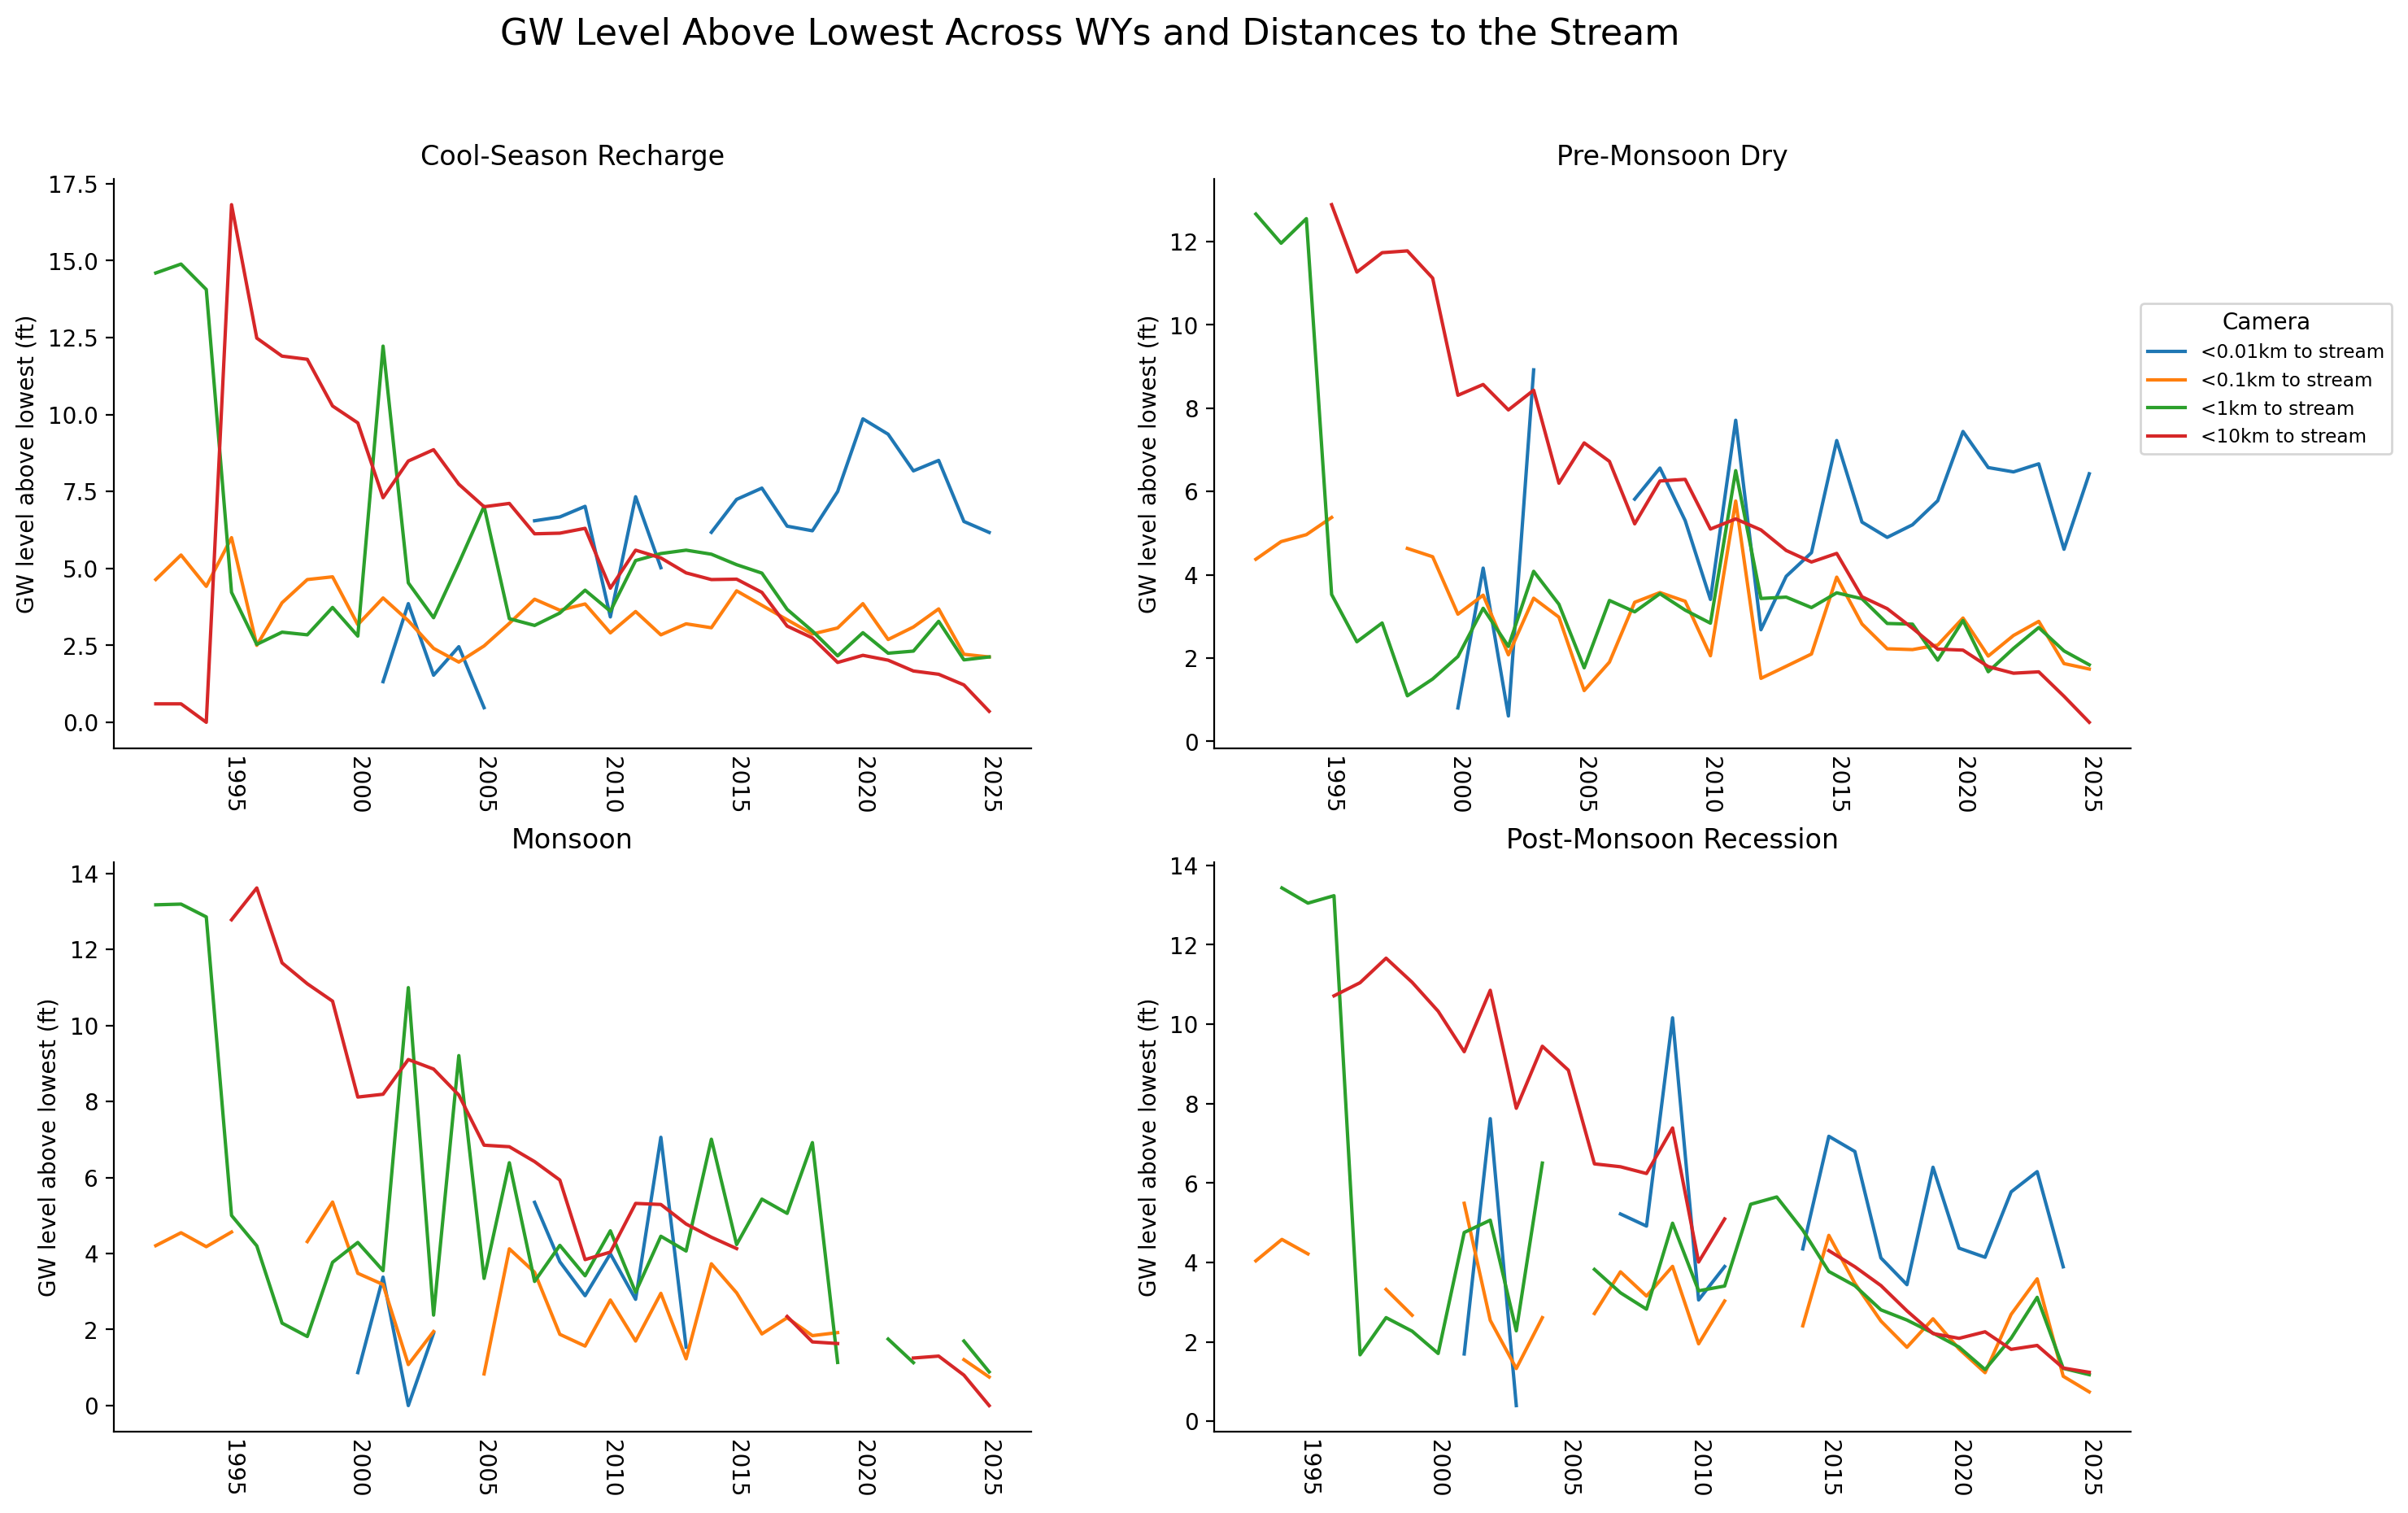

In [21]:
fig, axes = plt.subplots(2, 2, figsize = (16, 10))
ax1, ax2 = axes[0]
ax3, ax4 = axes[1]
fig.suptitle("GW Level Above Lowest Across WYs and Distances to the Stream", fontsize = 16)

cool = gw_seasons[gw_seasons["season"] == 1].pivot(index = "wy", columns = "subset", values = "height_abv_lowest_ft")

for site in cool.columns:
    ax1.plot(cool.index, cool[site], label = site + "km to stream")

ax1.spines[["top", "right"]].set_visible(False)
ax1.set_title("Cool-Season Recharge")
ax1.set_ylabel("GW level above lowest (ft)")
ax1.set_xticks(range(1995, 2030, 5))
ax1.tick_params(axis = "x", length = 0, labelrotation = 270)

dry = gw_seasons[gw_seasons["season"] == 2].pivot(index = "wy", columns = "subset", values = "height_abv_lowest_ft")
for site in dry.columns:
    ax2.plot(dry.index, dry[site], label = site + "km to stream")

ax2.spines[["top", "right"]].set_visible(False)
ax2.set_title("Pre-Monsoon Dry")
ax2.set_ylabel("GW level above lowest (ft)")
ax2.legend(title = "Camera", loc = "lower left", bbox_to_anchor = (1, 0.5), fontsize = "small")
ax2.set_xticks(range(1995, 2030, 5))
ax2.tick_params(axis = "x", length = 0, labelrotation = 270)

monsoon = gw_seasons[gw_seasons["season"] == 3].pivot(index = "wy", columns = "subset", values = "height_abv_lowest_ft")

for site in monsoon.columns:
    ax3.plot(monsoon.index, monsoon[site], label = site + "km to stream")

ax3.spines[["top", "right"]].set_visible(False)
ax3.set_title("Monsoon")
ax3.set_ylabel("GW level above lowest (ft)")
ax3.set_xticks(range(1995, 2030, 5))
ax3.tick_params(axis = "x", length = 0, labelrotation = 270)

recession = gw_seasons[gw_seasons["season"] == 4].pivot(index = "wy", columns = "subset", values = "height_abv_lowest_ft")

for site in recession.columns:
    ax4.plot(recession.index, recession[site], label = site + "km to stream")

ax4.spines[["top", "right"]].set_visible(False)
ax4.set_title("Post-Monsoon Recession")
ax4.set_ylabel("GW level above lowest (ft)")
ax4.set_xticks(range(1995, 2030, 5))
ax4.tick_params(axis = "x", length = 0, labelrotation = 270)

%config InlineBackend.figure_format = "retina"

# plt.savefig("gw_seasons.png", format = "png", dpi = 300, bbox_inches = "tight")

In [ ]:
# daily seasonal

# must test convergence and robustness to n with x1p and x2p

def blocked_embed(x, lag, embed):
    e = Embed(x)
    return e.embed_vectors_1d(lag, embed)

params = ["prcp", "tvpd", "temp"]

outputs = {"param": [],
           "season": [],
           "camera":[],
           "pearson": [],
           "param_predict_flow": [],
           "flow_predict_param": []}

for p in params:
    for s in range(1, 5):
        for c in sorted(names.values()):
            df2 = flow[(flow["Camera"] == c) & (flow["Season"] == s)]
            df2 = df2[["Date", "Flow Code"]].dropna()
            df1 = daymet[(daymet["camera"] == c) & (daymet["season"] == s)]
            df1 = df1[["date", p, "wy"]].dropna()
            df = df2.merge(df1, left_on = "Date", right_on = "date", how = "inner").drop(columns = ["Date", "date"])

            col_1 = p
            col_2 = "Flow Code"

            rho = df[col_1].corr(df[col_2])

            lag = 1
            embed = 2

            X1_blocks = []
            X2_blocks = []

            for y in sorted(df["wy"].unique()):
                year = df[df["wy"] == y]

                x1 = year[col_1].values
                x2 = year[col_2].values

                X1_blocks.append(blocked_embed(x1, lag, embed))
                X2_blocks.append(blocked_embed(x2, lag, embed))

            X1_embedded = np.vstack(X1_blocks)
            X2_embedded = np.vstack(X2_blocks)

            blocks = len(X1_blocks)
            split = int(0.8 * blocks)

            x1_tr = np.vstack(X1_blocks[:split])
            x1_te = np.vstack(X1_blocks[split:])

            x2_tr = np.vstack(X2_blocks[:split])
            x2_te = np.vstack(X2_blocks[split:])

            ccm = CCM()

            len_tr = len(x1_tr)
            lib_lens = np.arange(10, len_tr, 20, dtype = "int")

            ccm.fit(x1_tr, x2_tr)

            x1p, x2p = ccm.predict(x1_te, x2_te, lib_lengths = lib_lens)

            sc1, sc2 = ccm.score()

            outputs["param"].append(p)
            outputs["season"].append(s)
            outputs["camera"].append(c)
            outputs["pearson"].append(rho)
            outputs["param_predict_flow"].append(sc2[-1])
            outputs["flow_predict_param"].append(sc1[-1])

outputs = pd.DataFrame.from_dict(outputs)
outputs

c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_func

,param,season,camera,pearson,param_predict_flow,flow_predict_param
0,prcp,1,1,0.009799,-0.028018,-6.415025e-02
1,prcp,1,2,0.005311,NaN,NaN
2,prcp,1,3,NaN,NaN,NaN
3,prcp,1,4,0.009570,-0.049447,NaN
4,prcp,1,5,NaN,NaN,NaN
...,...,...,...,...,...,...
91,temp,4,4,-0.124638,0.049752,-1.709333e-01
92,temp,4,5,NaN,NaN,NaN
93,temp,4,6,-0.195176,0.005632,8.937359e-02
94,temp,4,7,-0.121539,-0.029164,3.013614e-01


In [24]:
names.values()

dict_values([7, 6, 1, 8, 2, 3, 4, 5, None, None, None, None])

In [ ]:
# seasonal aggregated - insufficient data for CCM

def extract(list):
    if len(list) > 0:
        return list[-1]
    else:
        return np.nan

params = ["prcp", "tvpd", "temp"]

outputs = {"param": [],
           "season": [],
           "camera":[],
           "pearson": [],
           "param_predict_flow": [],
           "flow_predict_param": []}

for p in params:
    for s in range(1, 5):
        for c in sorted(names.values()):
            df2 = flow[(flow["Camera"] == c) & (flow["Season"] == s)]
            df2 = df2.groupby("WY")["Flow Code"].mean().reset_index().dropna()
            df1 = daymet[(daymet["camera"] == c) & (daymet["season"] == s)]
            if p == "prcp":
                df1 = df1.groupby("wy")[[p]].sum().reset_index().dropna()
            else:
                df1 = df1.groupby("wy")[[p]].mean().reset_index().dropna()
            df = df2.merge(df1, left_on = "WY", right_on = "wy", how = "inner").drop(columns = ["WY", "wy"])

            col_1 = p
            col_2 = "Flow Code"

            rho = df[col_1].corr(df[col_2])

            lag = 1
            embed = 2

            x1 = df[col_1].values
            x2 = df[col_2].values

            e1 = Embed(x1)
            e2 = Embed(x2)
            X1_embedded = e1.embed_vectors_1d(lag, embed)
            X2_embedded = e2.embed_vectors_1d(lag, embed)

            x1_tr, x1_te, x2_tr, x2_te = X1_embedded, X1_embedded, X2_embedded, X2_embedded # has not been updated with train/test split

            ccm = CCM()

            len_tr = len(x1_tr)
            lib_lens = np.arange(10, len_tr, 20, dtype = "int")

            ccm.fit(x1_tr, x2_tr)

            x1p, x2p = ccm.predict(x1_te, x2_te, lib_lengths=lib_lens)

            sc1, sc2 = ccm.score()

            outputs["param"].append(p)
            outputs["season"].append(s)
            outputs["camera"].append(c)
            outputs["pearson"].append(rho)
            outputs["param_predict_flow"].append(extract(sc2))
            outputs["flow_predict_param"].append(extract(sc1))

outputs = pd.DataFrame.from_dict(outputs)
outputs

In [50]:
# annual daily

params = ["prcp", "tvpd", "temp"]

outputs = {"param": [],
           "camera":[],
           "pearson": [],
           "param_predict_flow": [],
           "flow_predict_param": []}

for p in params:
    for c in sorted(names.values()):
        df2 = flow[(flow["Camera"] == c)]
        df2 = df2[["Date", "Flow Code"]].dropna()
        df1 = daymet[(daymet["camera"] == c)]
        df1 = df1[["date", p]].dropna()
        df = df2.merge(df1, left_on = "Date", right_on = "date", how = "inner").drop(columns = ["Date", "date"])

        col_1 = p
        col_2 = "Flow Code"

        rho = df[col_1].corr(df[col_2])

        lag = 1
        embed = 2

        x1 = df[col_1].values
        x2 = df[col_2].values

        e1 = Embed(x1)
        e2 = Embed(x2)
        X1_embedded = e1.embed_vectors_1d(lag, embed)
        X2_embedded = e2.embed_vectors_1d(lag, embed)

        split = int(0.5 * len(X1_embedded))

        x1_tr = X1_embedded[:split]
        x1_te = X1_embedded[split:]
        x2_tr = X2_embedded[:split]
        x2_te = X2_embedded[split:]

        ccm = CCM()

        len_tr = len(x1_tr)
        lib_lens = np.arange(10, len_tr, 20, dtype = "int")

        ccm.fit(x1_tr, x2_tr)

        x1p, x2p = ccm.predict(x1_te, x2_te, lib_lengths = lib_lens)

        sc1, sc2 = ccm.score()

        outputs["param"].append(p)
        outputs["camera"].append(c)
        outputs["pearson"].append(rho)
        outputs["param_predict_flow"].append(sc2[-1])
        outputs["flow_predict_param"].append(sc1[-1])

outputs = pd.DataFrame.from_dict(outputs)
outputs

c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\tiffa\anaconda3\Lib\site-packages\numpy\lib\_func

,param,camera,pearson,param_predict_flow,flow_predict_param
0,prcp,1,0.038228,-0.009582,-1.458768e-02
1,prcp,2,0.015173,0.026451,4.574392e-02
2,prcp,3,NaN,NaN,1.930720e-18
3,prcp,4,0.020873,0.019543,-7.352376e-03
4,prcp,5,0.012306,-0.009425,NaN
5,prcp,6,0.100076,0.020384,2.539165e-02
6,prcp,7,0.072489,-0.044113,1.213112e-02
7,prcp,8,-0.054510,0.033425,1.460714e-02
8,tvpd,1,-0.557987,0.413924,4.620819e-01
9,tvpd,2,-0.531618,0.426694,4.309455e-01


In [ ]:
params = ["prcp", "tvpd", "temp"]

outputs = {"param": [],
           "season": [],
           "camera":[],
           "pearson": [],
           "param_predict_flow": [],
           "flow_predict_param": []}

for p in params:
    for s in range(1, 5):
        for c in sorted(names.values()):
            df2 = flow[(flow["Camera"] == c) & (flow["Season"] == s)]
            df2 = df2[["Date", "Flow Code"]].dropna()
            df1 = daymet[(daymet["camera"] == c) & (daymet["season"] == s)]
            df1 = df1[["date", p]].dropna()
            df = df2.merge(df1, left_on = "Date", right_on = "date", how = "inner").drop(columns = ["Date", "date"])

            col_1 = p
            col_2 = "Flow Code"

            rho = df[col_1].corr(df[col_2])

            lag = 1
            embed = 2

            x1 = df[col_1].values
            x2 = df[col_2].values

            e1 = Embed(x1)
            e2 = Embed(x2)
            X1_embedded = e1.embed_vectors_1d(lag, embed)
            X2_embedded = e2.embed_vectors_1d(lag, embed)

            x1_tr, x1_te, x2_tr, x2_te = X1_embedded, X1_embedded, X2_embedded, X2_embedded

            ccm = CCM()

            len_tr = len(x1_tr)
            lib_lens = np.arange(10, len_tr, 20, dtype = "int")

            ccm.fit(x1_tr, x2_tr)

            x1p, x2p = ccm.predict(x1_te, x2_te, lib_lengths=lib_lens)

            sc1, sc2 = ccm.score()

            outputs["param"].append(p)
            outputs["season"].append(s)
            outputs["camera"].append(c)
            outputs["pearson"].append(rho)
            outputs["param_predict_flow"].append(sc2[-1])
            outputs["flow_predict_param"].append(sc1[-1])

outputs = pd.DataFrame.from_dict(outputs)
outputs

In [42]:
outputs = {"season": [],
           "subset":[],
           "pearson": [],
           "param_predict_flow": [],
           "flow_predict_param": []}

for s in range(1, 5):
    for subset in ["<0.01", "<0.1", "<1", "<10"]:
        df2 = flow[flow["Season"] == s]
        df2 = df2.groupby("WY")["Flow Code"].mean().reset_index().dropna()
        df1 = gw_seasons[(gw_seasons["subset"] == subset) & (gw_seasons["season"] == s)][["wy", "height_abv_lowest_ft"]].dropna()
        df = df2.merge(df1, left_on = "WY", right_on = "wy", how = "inner").drop(columns = ["WY", "wy"])

        col_1 = "height_abv_lowest_ft"
        col_2 = "Flow Code"

        rho = df[col_1].corr(df[col_2])

        lag = 1
        embed = 2

        x1 = df[col_1].values
        x2 = df[col_2].values

        e1 = Embed(x1)
        e2 = Embed(x2)
        X1_embedded = e1.embed_vectors_1d(lag, embed)
        X2_embedded = e2.embed_vectors_1d(lag, embed)

        x1_tr, x1_te, x2_tr, x2_te = X1_embedded, X1_embedded, X2_embedded, X2_embedded

        ccm = CCM()

        len_tr = len(x1_tr)
        lib_lens = np.arange(10, len_tr, 20, dtype = "int")

        ccm.fit(x1_tr, x2_tr)

        x1p, x2p = ccm.predict(x1_te, x2_te, lib_lengths=lib_lens)

        sc1, sc2 = ccm.score()

        outputs["season"].append(s)
        outputs["subset"].append(subset)
        outputs["pearson"].append(rho)
        outputs["param_predict_flow"].append(extract(sc2))
        outputs["flow_predict_param"].append(extract(sc1))

outputs = pd.DataFrame.from_dict(outputs)
outputs

,season,subset,pearson,param_predict_flow,flow_predict_param
0,1,<0.01,0.154213,0.382086,0.523572
1,1,<0.1,0.393049,0.640877,0.695860
2,1,<1,0.298510,0.411337,0.309630
3,1,<10,-0.075118,0.587490,0.550844
4,2,<0.01,0.049741,0.340602,0.779245
5,2,<0.1,0.581994,0.566620,0.947299
6,2,<1,0.600493,0.603832,0.800034
7,2,<10,0.513564,0.405004,0.257266
8,3,<0.01,-0.176092,NaN,NaN
9,3,<0.1,0.486781,0.683642,0.831371


In [ ]:
outputs = {"subset":[],
           "pearson": [],
           "param_predict_flow": [],
           "flow_predict_param": []}

for subset in ["<0.01", "<0.1", "<1", "<10"]:
    df2 = df2.groupby("WY")["Flow Code"].mean().reset_index().dropna()
    df1 = gw[gw["subset"] == subset]
    df1 = df1.groupby("wy")["height_abv_lowest_ft"].mean().reset_index().dropna()
    df = df2.merge(df1, left_on = "WY", right_on = "wy", how = "inner").drop(columns = ["WY", "wy"])

    col_1 = "height_abv_lowest_ft"
    col_2 = "Flow Code"

    rho = df[col_1].corr(df[col_2])

    lag = 1
    embed = 2

    x1 = df[col_1].values
    x2 = df[col_2].values

    e1 = Embed(x1)
    e2 = Embed(x2)
    X1_embedded = e1.embed_vectors_1d(lag, embed)
    X2_embedded = e2.embed_vectors_1d(lag, embed)

    x1_tr, x1_te, x2_tr, x2_te = X1_embedded, X1_embedded, X2_embedded, X2_embedded

    ccm = CCM()

    len_tr = len(x1_tr)
    lib_lens = np.arange(10, len_tr, 20, dtype = "int")

    ccm.fit(x1_tr, x2_tr)

    x1p, x2p = ccm.predict(x1_te, x2_te, lib_lengths=lib_lens)

    sc1, sc2 = ccm.score()

    outputs["subset"].append(subset)
    outputs["pearson"].append(rho)
    outputs["param_predict_flow"].append(extract(sc2))
    outputs["flow_predict_param"].append(extract(sc1))

outputs = pd.DataFrame.from_dict(outputs)
outputs

,subset,pearson,param_predict_flow,flow_predict_param
0,<0.01,0.120268,0.398644,0.520337
1,<0.1,0.695365,0.625059,0.700381
2,<1,0.704876,0.628940,0.413312
3,<10,0.572699,0.395870,0.221234


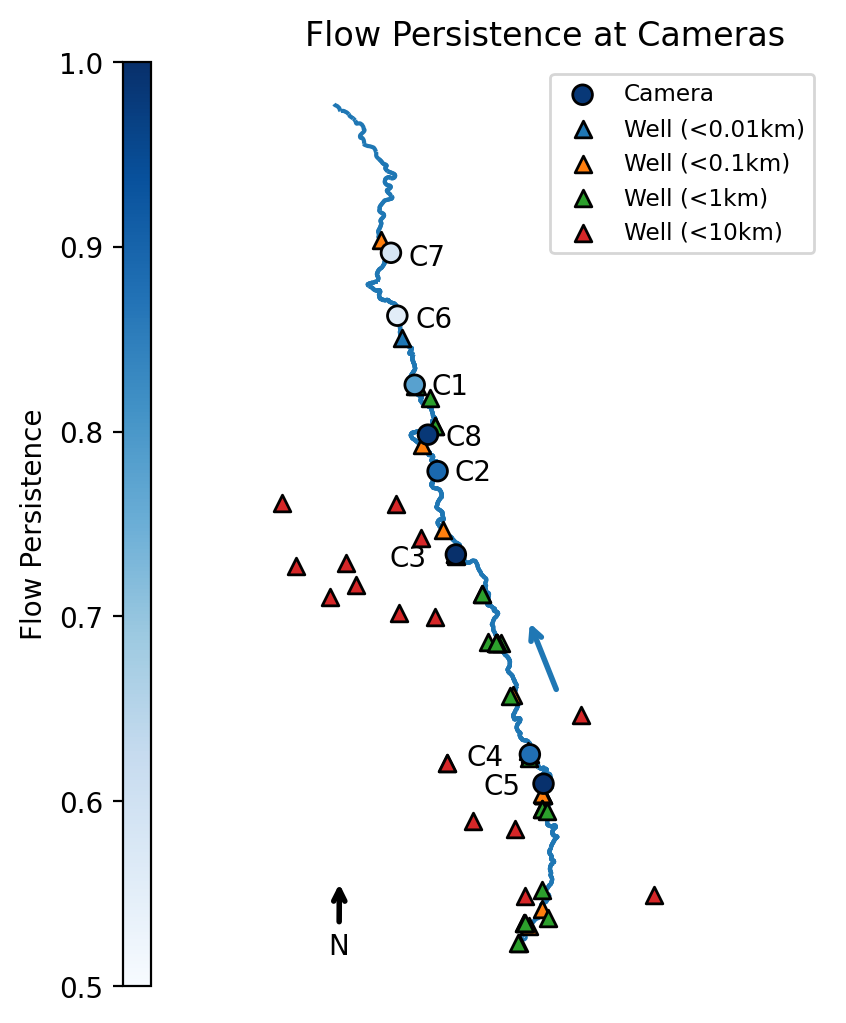

In [ ]:
streamline = gpd.read_file("USPP_reach.shp")

persistence = (
    flow
    .dropna(subset = ["Flow Code"])
    .assign(Persistence = flow["Flow Code"].isin([1, 2]))
    .groupby("Site")
    .agg(
        Persistence = ("Persistence", "mean"),
        Longitude = ("Longitude", "first"),
        Latitude = ("Latitude", "first")
    )
)
persistence = gpd.GeoDataFrame(persistence, geometry = gpd.points_from_xy(persistence["Longitude"], persistence["Latitude"]))

wells = gw.groupby("site_no").agg(geometry = ("geometry", "first"), subset = ("subset", "first"))
wells = gpd.GeoDataFrame(wells, geometry = wells["geometry"])

fig, ax = plt.subplots(figsize = (8, 6))

ax.annotate("", xy = (-110.12, 31.57), xytext = (-110.1, 31.52), arrowprops = dict(arrowstyle = "->", color = "tab:blue", linewidth = 2), zorder = 3)
ax.annotate("N", xy = (-110.243, 31.4), xytext = (-110.25, 31.35), arrowprops = dict(arrowstyle = "->", color = "black", linewidth = 2), zorder = 3)

norm = mpl.colors.Normalize(vmin = 0.5, vmax = 1)

streamline.plot(ax = ax, zorder = 1)
persistence.plot(column = "Persistence", ax = ax, cmap = "Blues", markersize = 50, norm = norm, edgecolor = "black", label = "Camera", zorder = 3)
wells[wells["subset"] == "<0.01"].plot(ax = ax, marker = "^", color = "#1f77b4", edgecolor = "black", label = "Well (<0.01km)", zorder = 2)
wells[wells["subset"] == "<0.1"].plot(ax = ax, marker = "^", color = "#ff7f0e", edgecolor = "black", label = "Well (<0.1km)", zorder = 2)
wells[wells["subset"] == "<1"].plot(ax = ax, marker = "^", color = "#2ca02c", edgecolor = "black", label = "Well (<1km)", zorder = 2)
wells[wells["subset"] == "<10"].plot(ax = ax, marker = "^", color = "#d62728", edgecolor = "black", label = "Well (<10km)", zorder = 2)

ax.set_title("Flow Persistence at Cameras")
ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1] + 0.1)
ax.legend(loc = "upper right", fontsize = "small")

divider = make_axes_locatable(ax) # understands size and position of axes
cax = divider.append_axes("left", size = "5%") # adds new axis
sm = mpl.cm.ScalarMappable(cmap = "Blues", norm = norm) # maps values to colors for colorbar
cbar = fig.colorbar(sm, cax = cax)
cbar.set_label("Flow Persistence")
cbar.ax.yaxis.set_label_position("left")
cbar.ax.yaxis.set_ticks_position("left")

ax.text(-110.198, 31.8, "C7", zorder = 4)
ax.text(-110.193, 31.76, "C6", zorder = 4)
ax.text(-110.183, 31.716, "C1", zorder = 4)
ax.text(-110.174, 31.683, "C8", zorder = 4)
ax.text(-110.168, 31.66, "C2", zorder = 4)
ax.text(-110.21, 31.604, "C3", zorder = 4)
ax.text(-110.16, 31.474, "C4", zorder = 4)
ax.text(-110.149, 31.455, "C5", zorder =4)

ax.set_axis_off()

%config InlineBackend.figure_format = "retina"

# plt.savefig("fp_wells.png", format = "png", dpi = 300, bbox_inches = "tight")

In [10]:
et = pd.read_csv("DATA/ET/MODIS.csv")
et["Date"] = pd.to_datetime(et["Date"])

In [11]:
et

,Date,ET,Site,Buffer,Source,Camera,WY,Season
0,2000-10-07,67.128230,Fairbank,50,ET_Fairbankbuffer50MODIS.csv,1,2001,4
1,2000-10-07,58.481479,CharlestonMesquite,50,ET_CharlestonMesquitebuffer50MODIS.csv,2,2001,4
2,2000-10-07,50.938603,Moson,50,ET_Mosonbuffer50MODIS.csv,3,2001,4
3,2000-10-07,52.056128,Hunter,50,ET_Hunterbuffer50MODIS.csv,4,2001,4
4,2000-10-07,54.574479,Hereford,50,ET_Herefordbuffer50MODIS.csv,5,2001,4
...,...,...,...,...,...,...,...,...
64395,2025-09-30,39.696212,Hunter,50000,ET_Hunterbuffer50000MODIS.csv,4,2025,3
64396,2025-09-30,47.069953,Hereford,50000,ET_Herefordbuffer50000MODIS.csv,5,2025,3
64397,2025-09-30,29.190381,Contention,50000,ET_Contentionbuffer50000MODIS.csv,6,2025,3
64398,2025-09-30,35.128591,St.David,50000,ET_St.Davidbuffer50000MODIS.csv,7,2025,3
